
MEDICINAL CHEMISTRY FILTERS: BRENK, NIH, and PAINS

Please upload your compound file (CSV format)
The file should contain at least 'smiles' and 'compound_name' columns.
If these columns are not present, the script will try to infer them.


Saving Input file for part-3 after completed part-2.csv to Input file for part-3 after completed part-2 (1).csv
Using uploaded file: Input file for part-3 after completed part-2 (1).csv

Dataset shape: (84059, 2)

First 5 rows of data:
  compound_name                                             smiles
0         CNP-7  CC(C)(C)C(=O)OCOC(=O)C1N2C(=O)C(NC(=O)C(N)c3cc...
1        CNP-78  COCOC(=O)C1N2C(=O)C(N3C(=O)C(c4ccc(O)cc4)NC3(C...
2        CNP-93     CC1(C)S[C@@H]2C(/N=C/N3CCCCCC3)C(=O)N2C1C(=O)O
3        CNP-95  COc1ccc2c3c1OC1C(=O)CC[C@H]4[C@@H](C2)N(C)CC[C...
4       CNP-138           Cc1nc2c(=O)n(C)c(=O)n(CC3CC=CCC3)c2[nH]1

Adding molecule representations...


Failed to patch pandas - unable to change molecule rendering



Visualizing example molecules from the dataset:


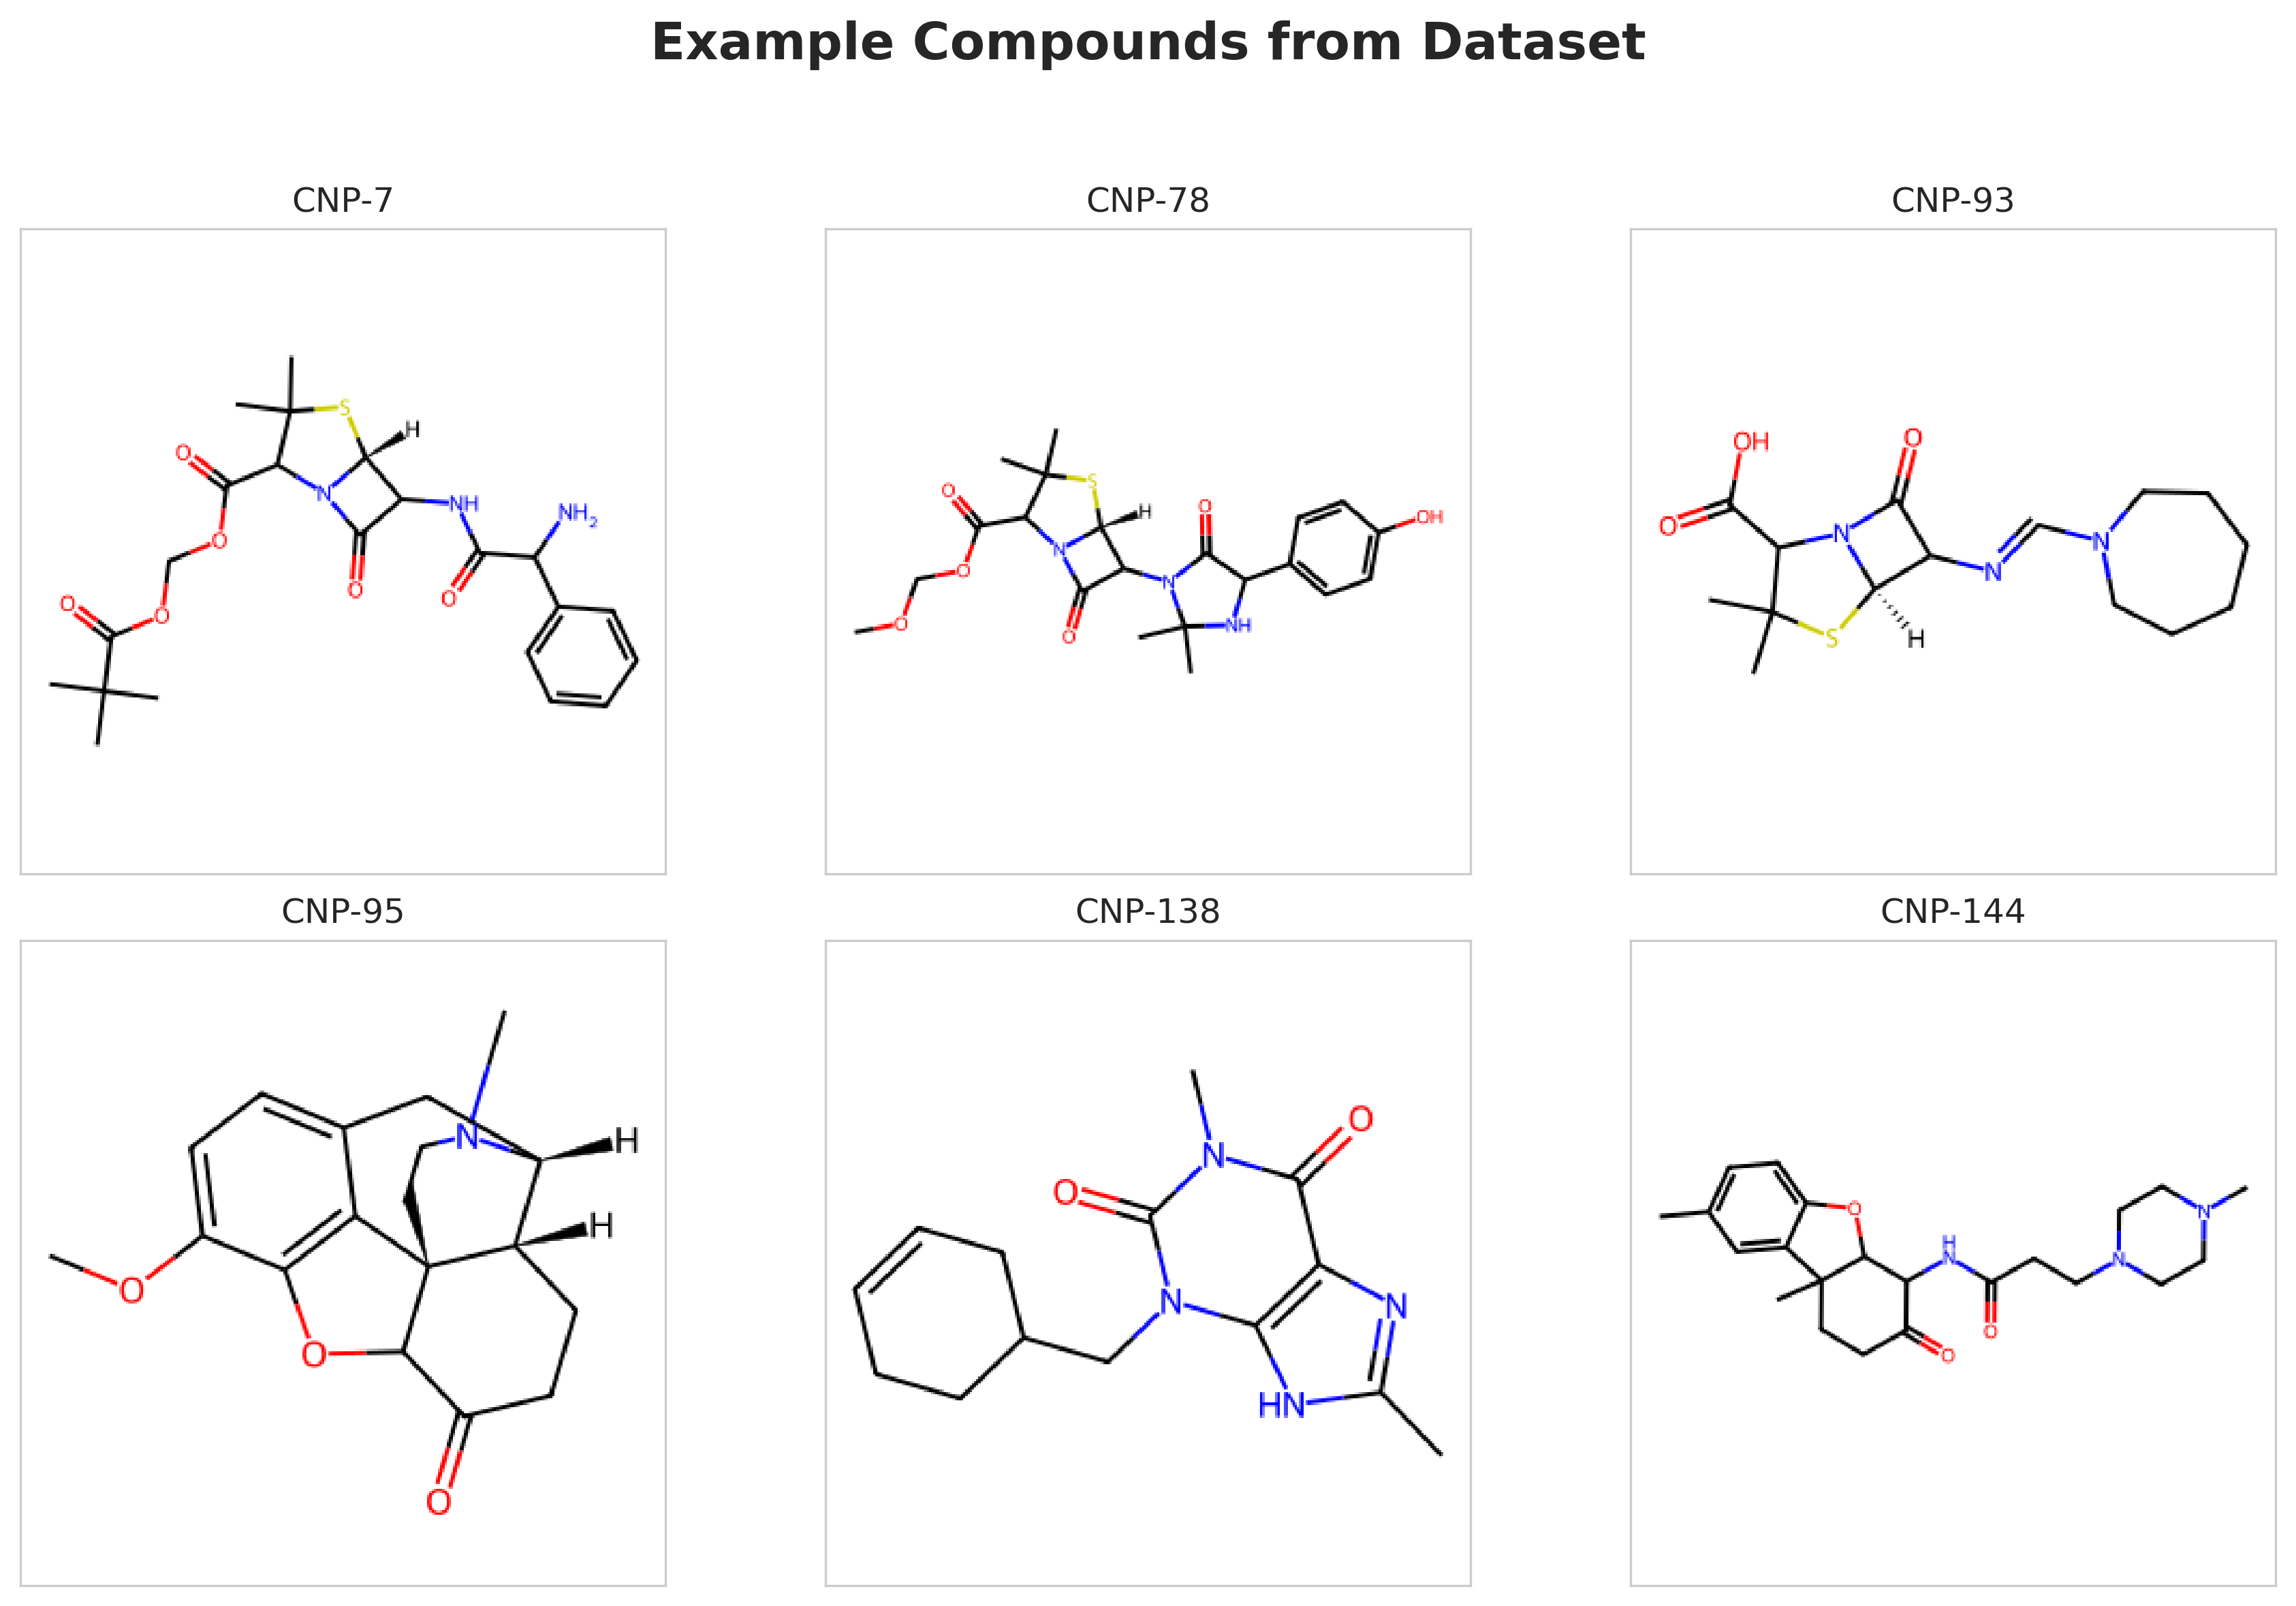



STEP 1: Applying Brenk Filter


Applying Brenk filter:   0%|          | 0/84059 [00:00<?, ?it/s]


Removed 49765 compounds using Brenk filter.
Remaining compounds: 34294

Visualizing examples of compounds filtered by Brenk:


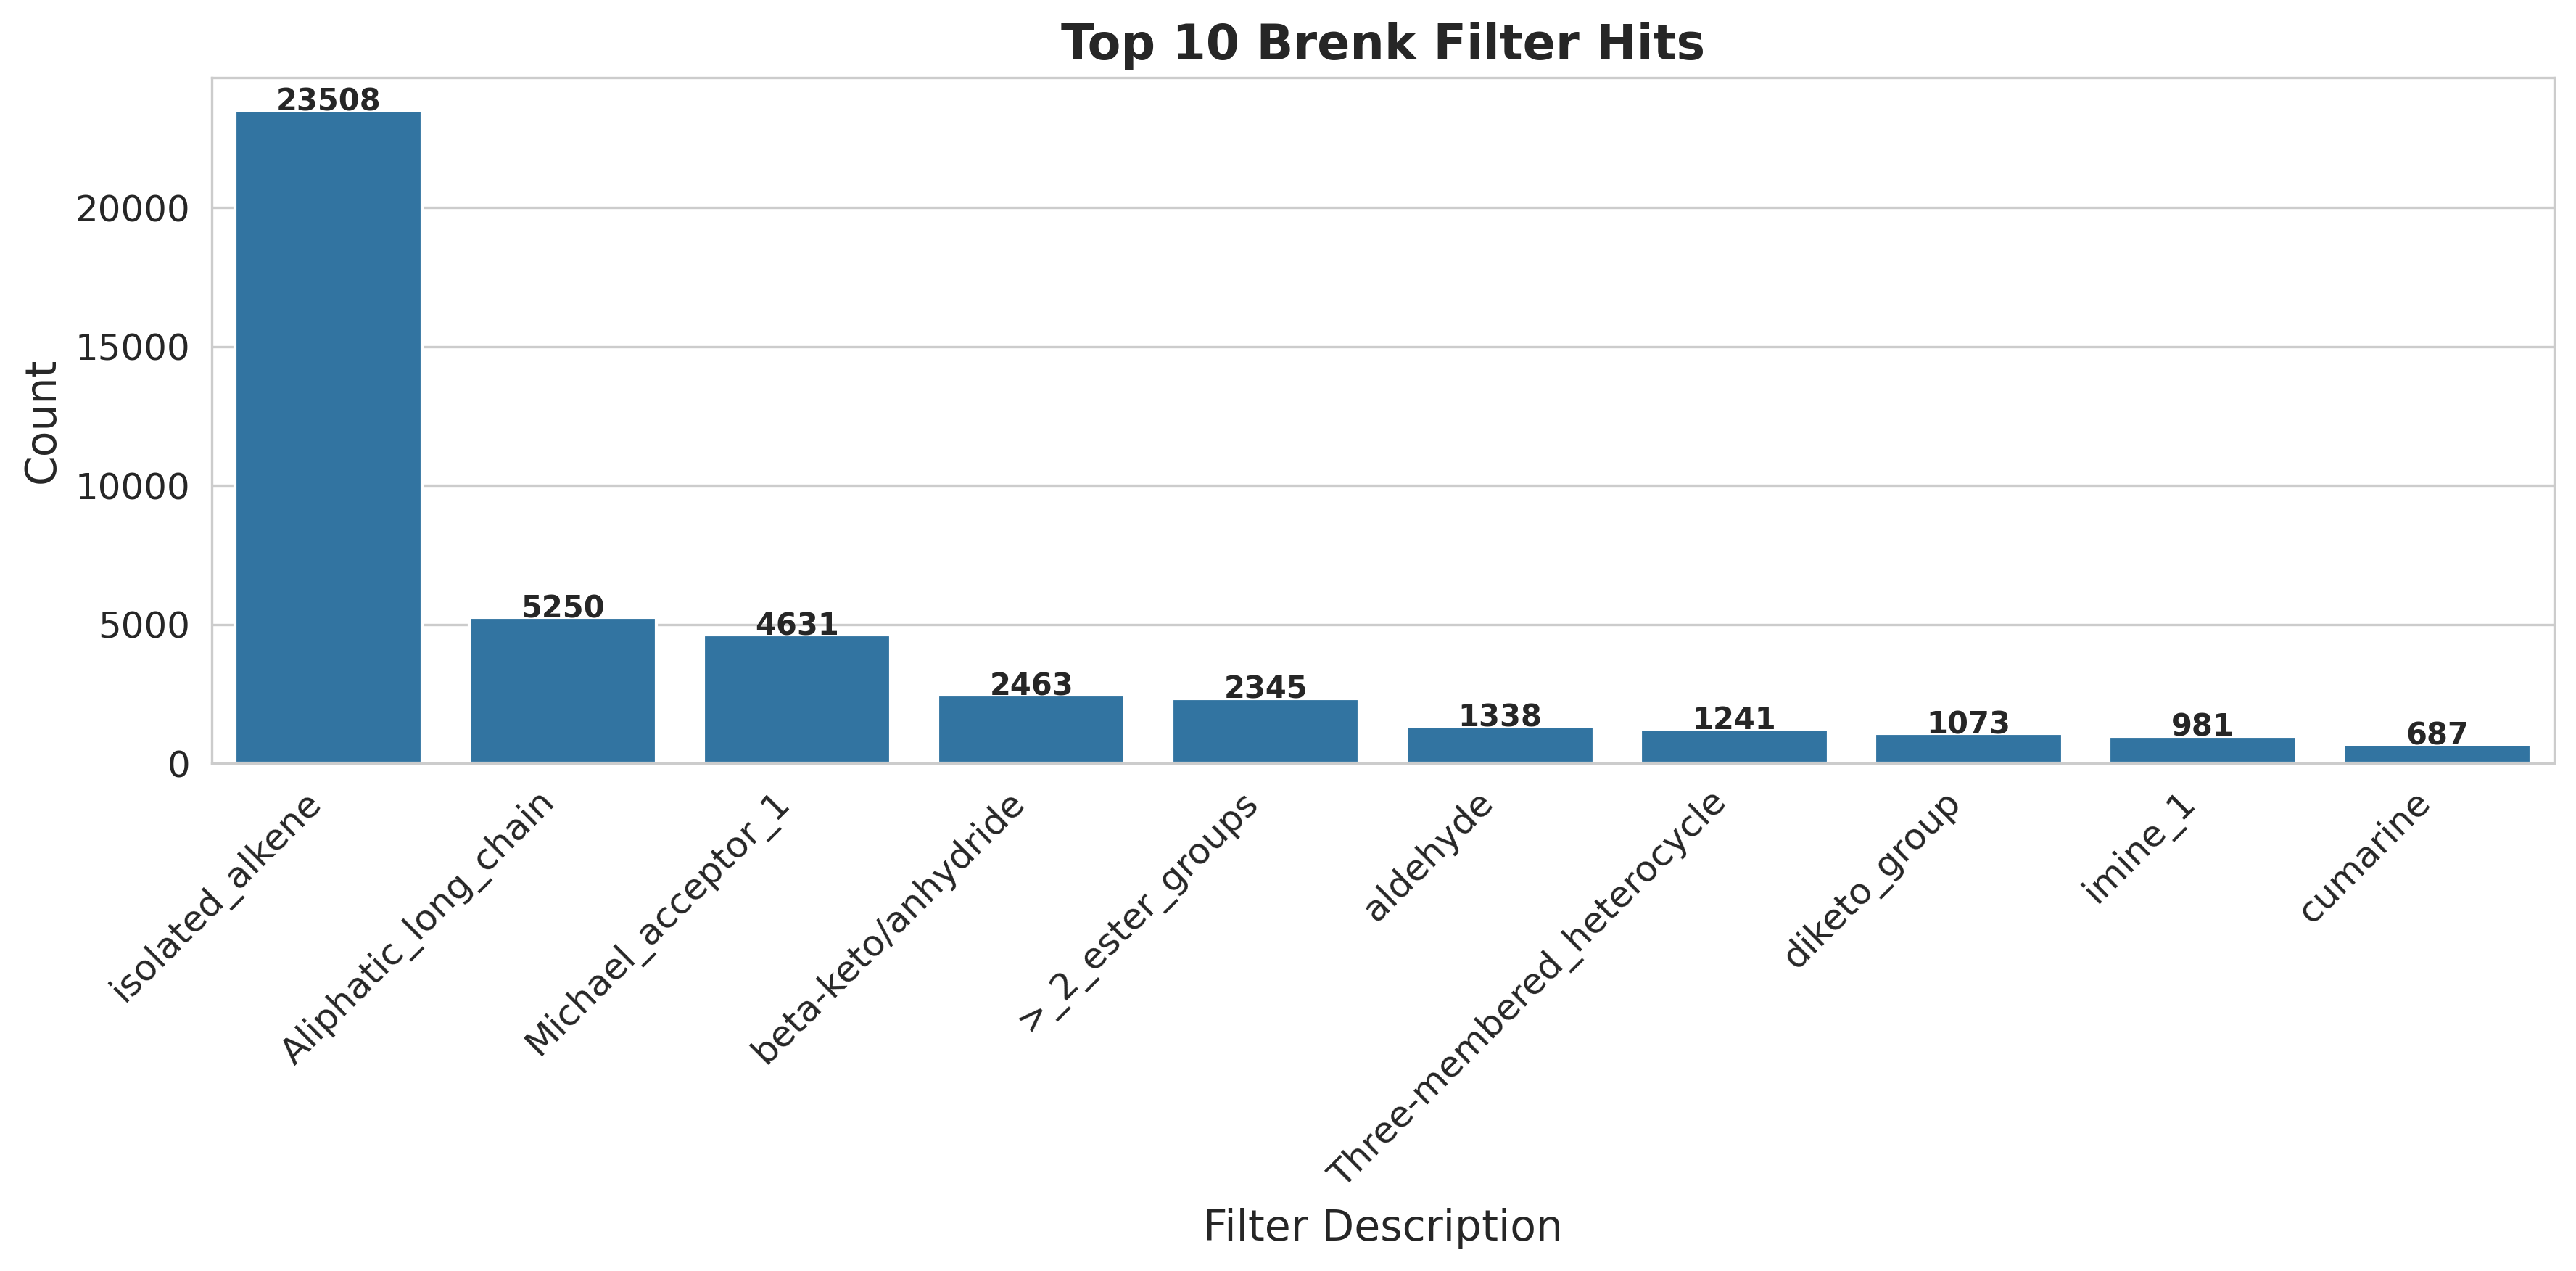

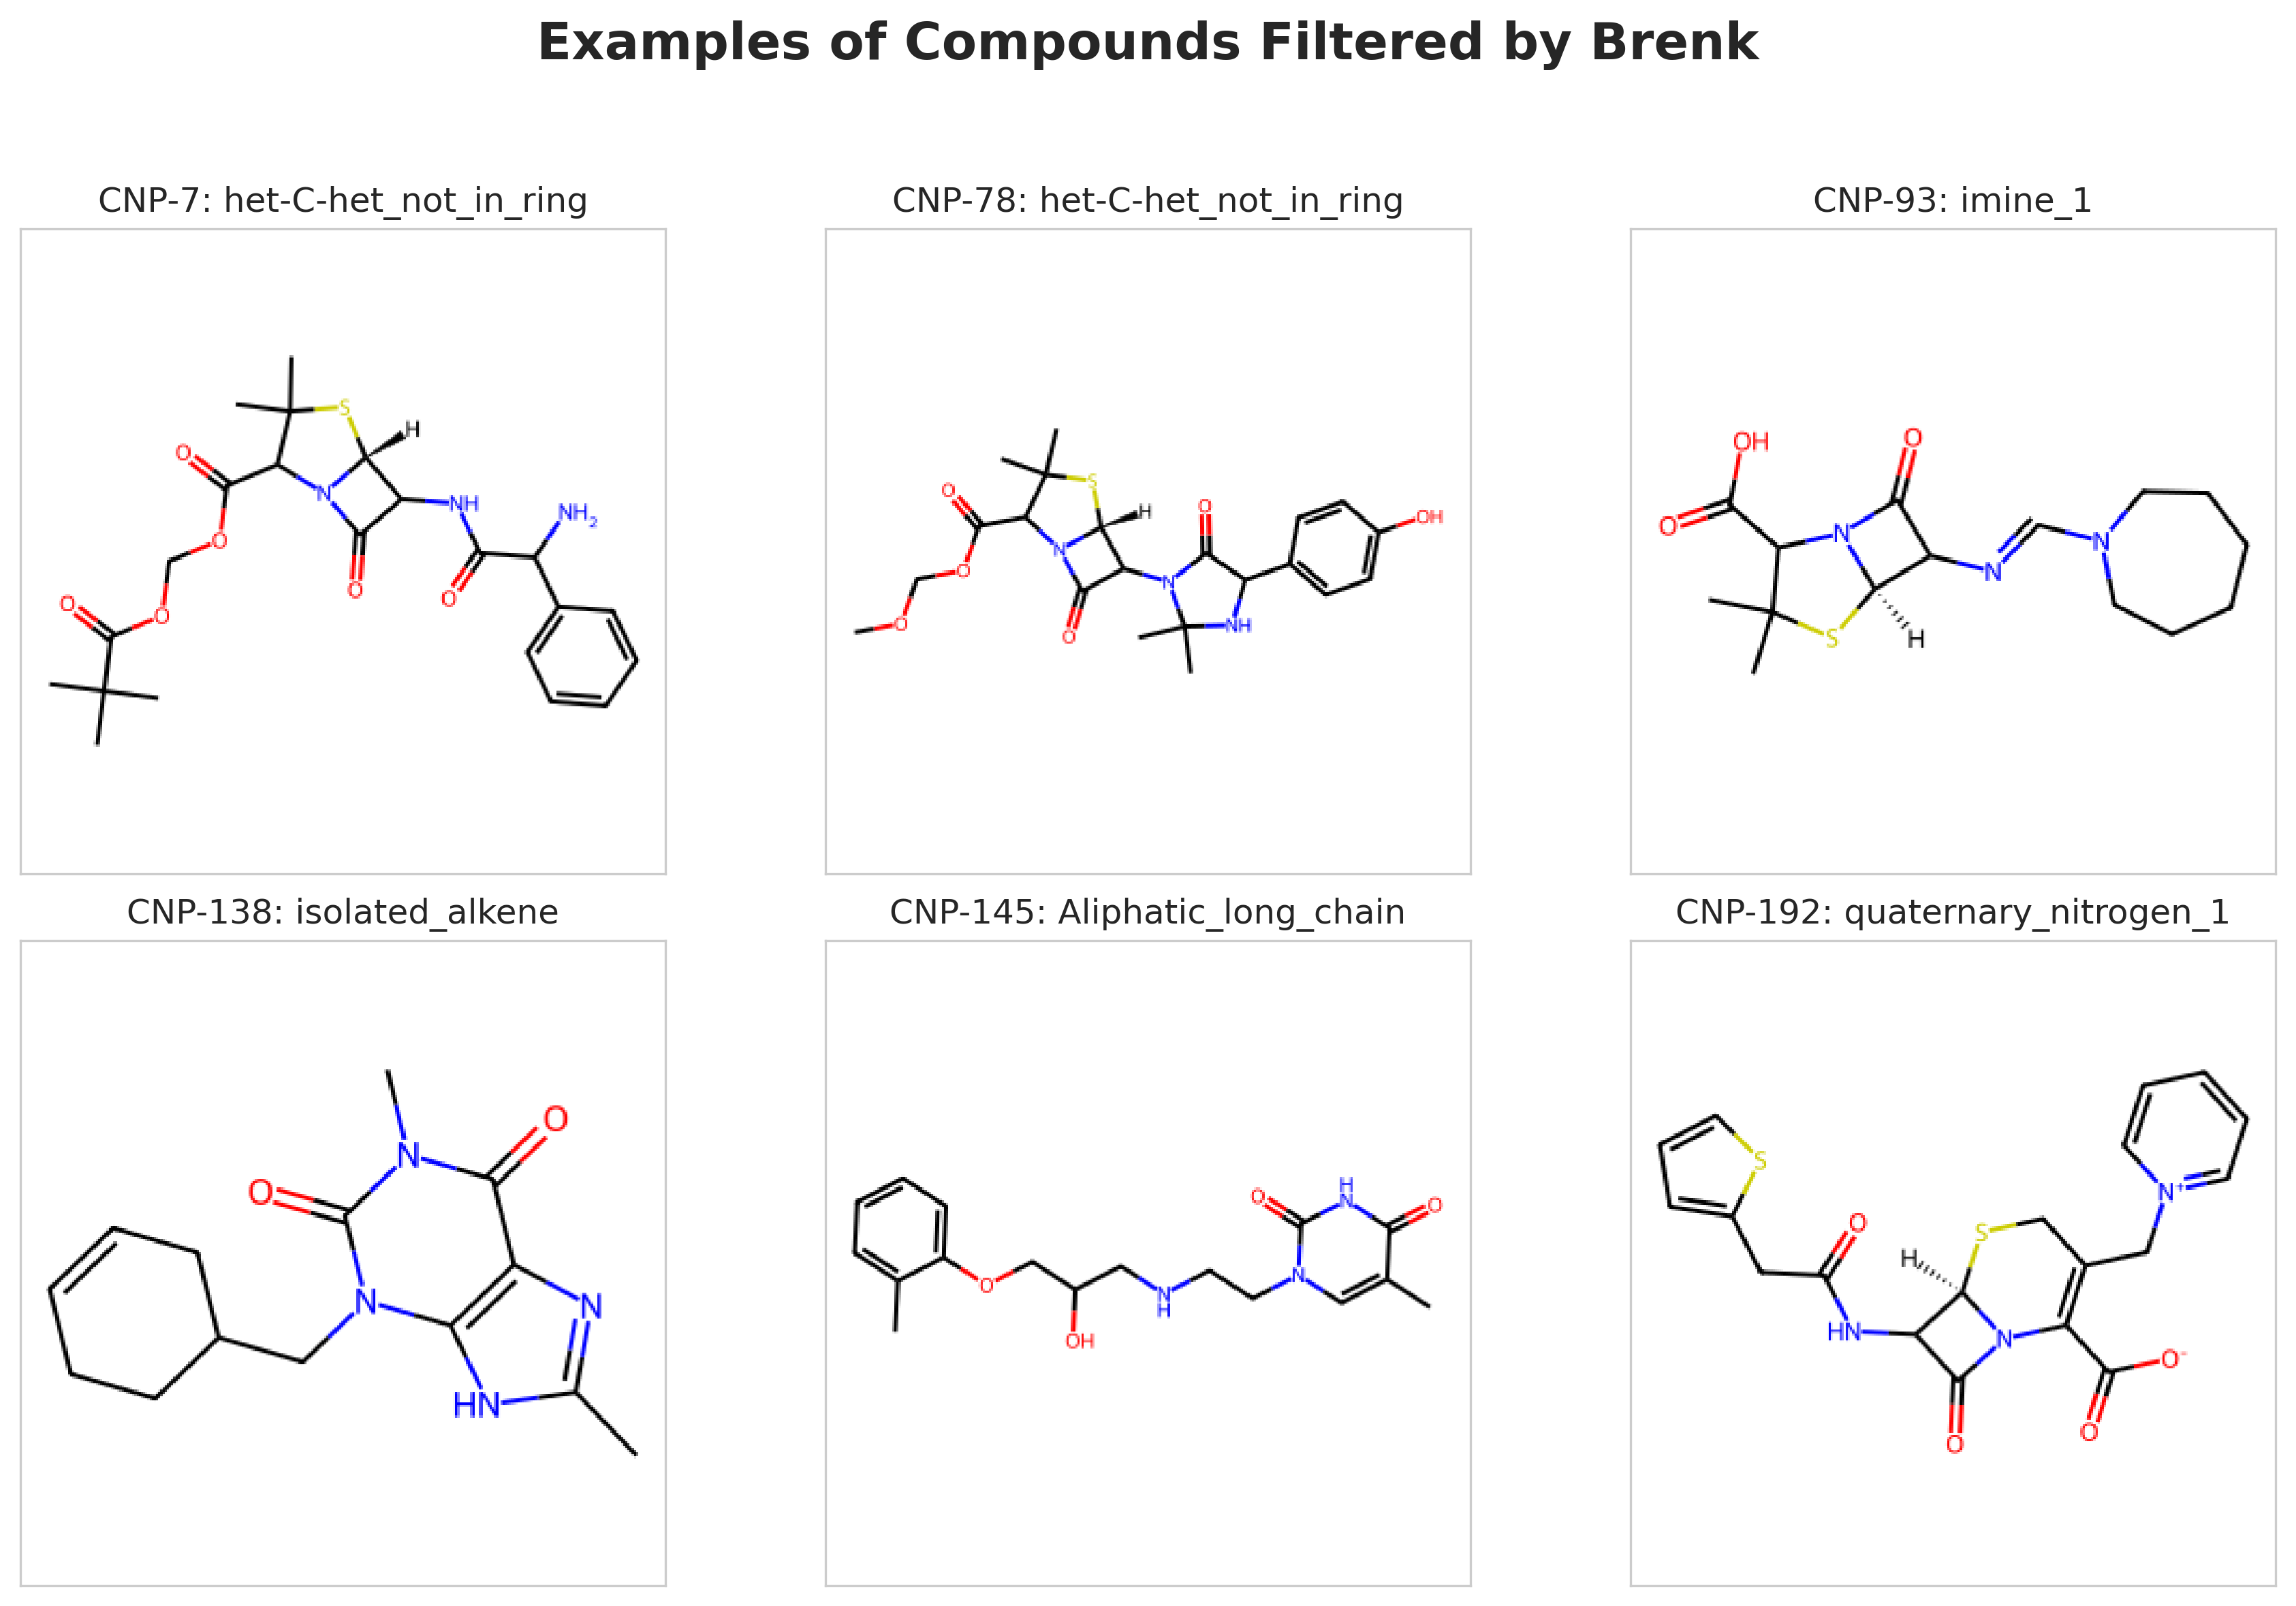



STEP 2: Applying NIH Filter


Applying NIH filter:   0%|          | 0/34294 [00:00<?, ?it/s]


Removed 299 compounds using NIH filter.
Remaining compounds: 33995

Visualizing examples of compounds filtered by NIH:


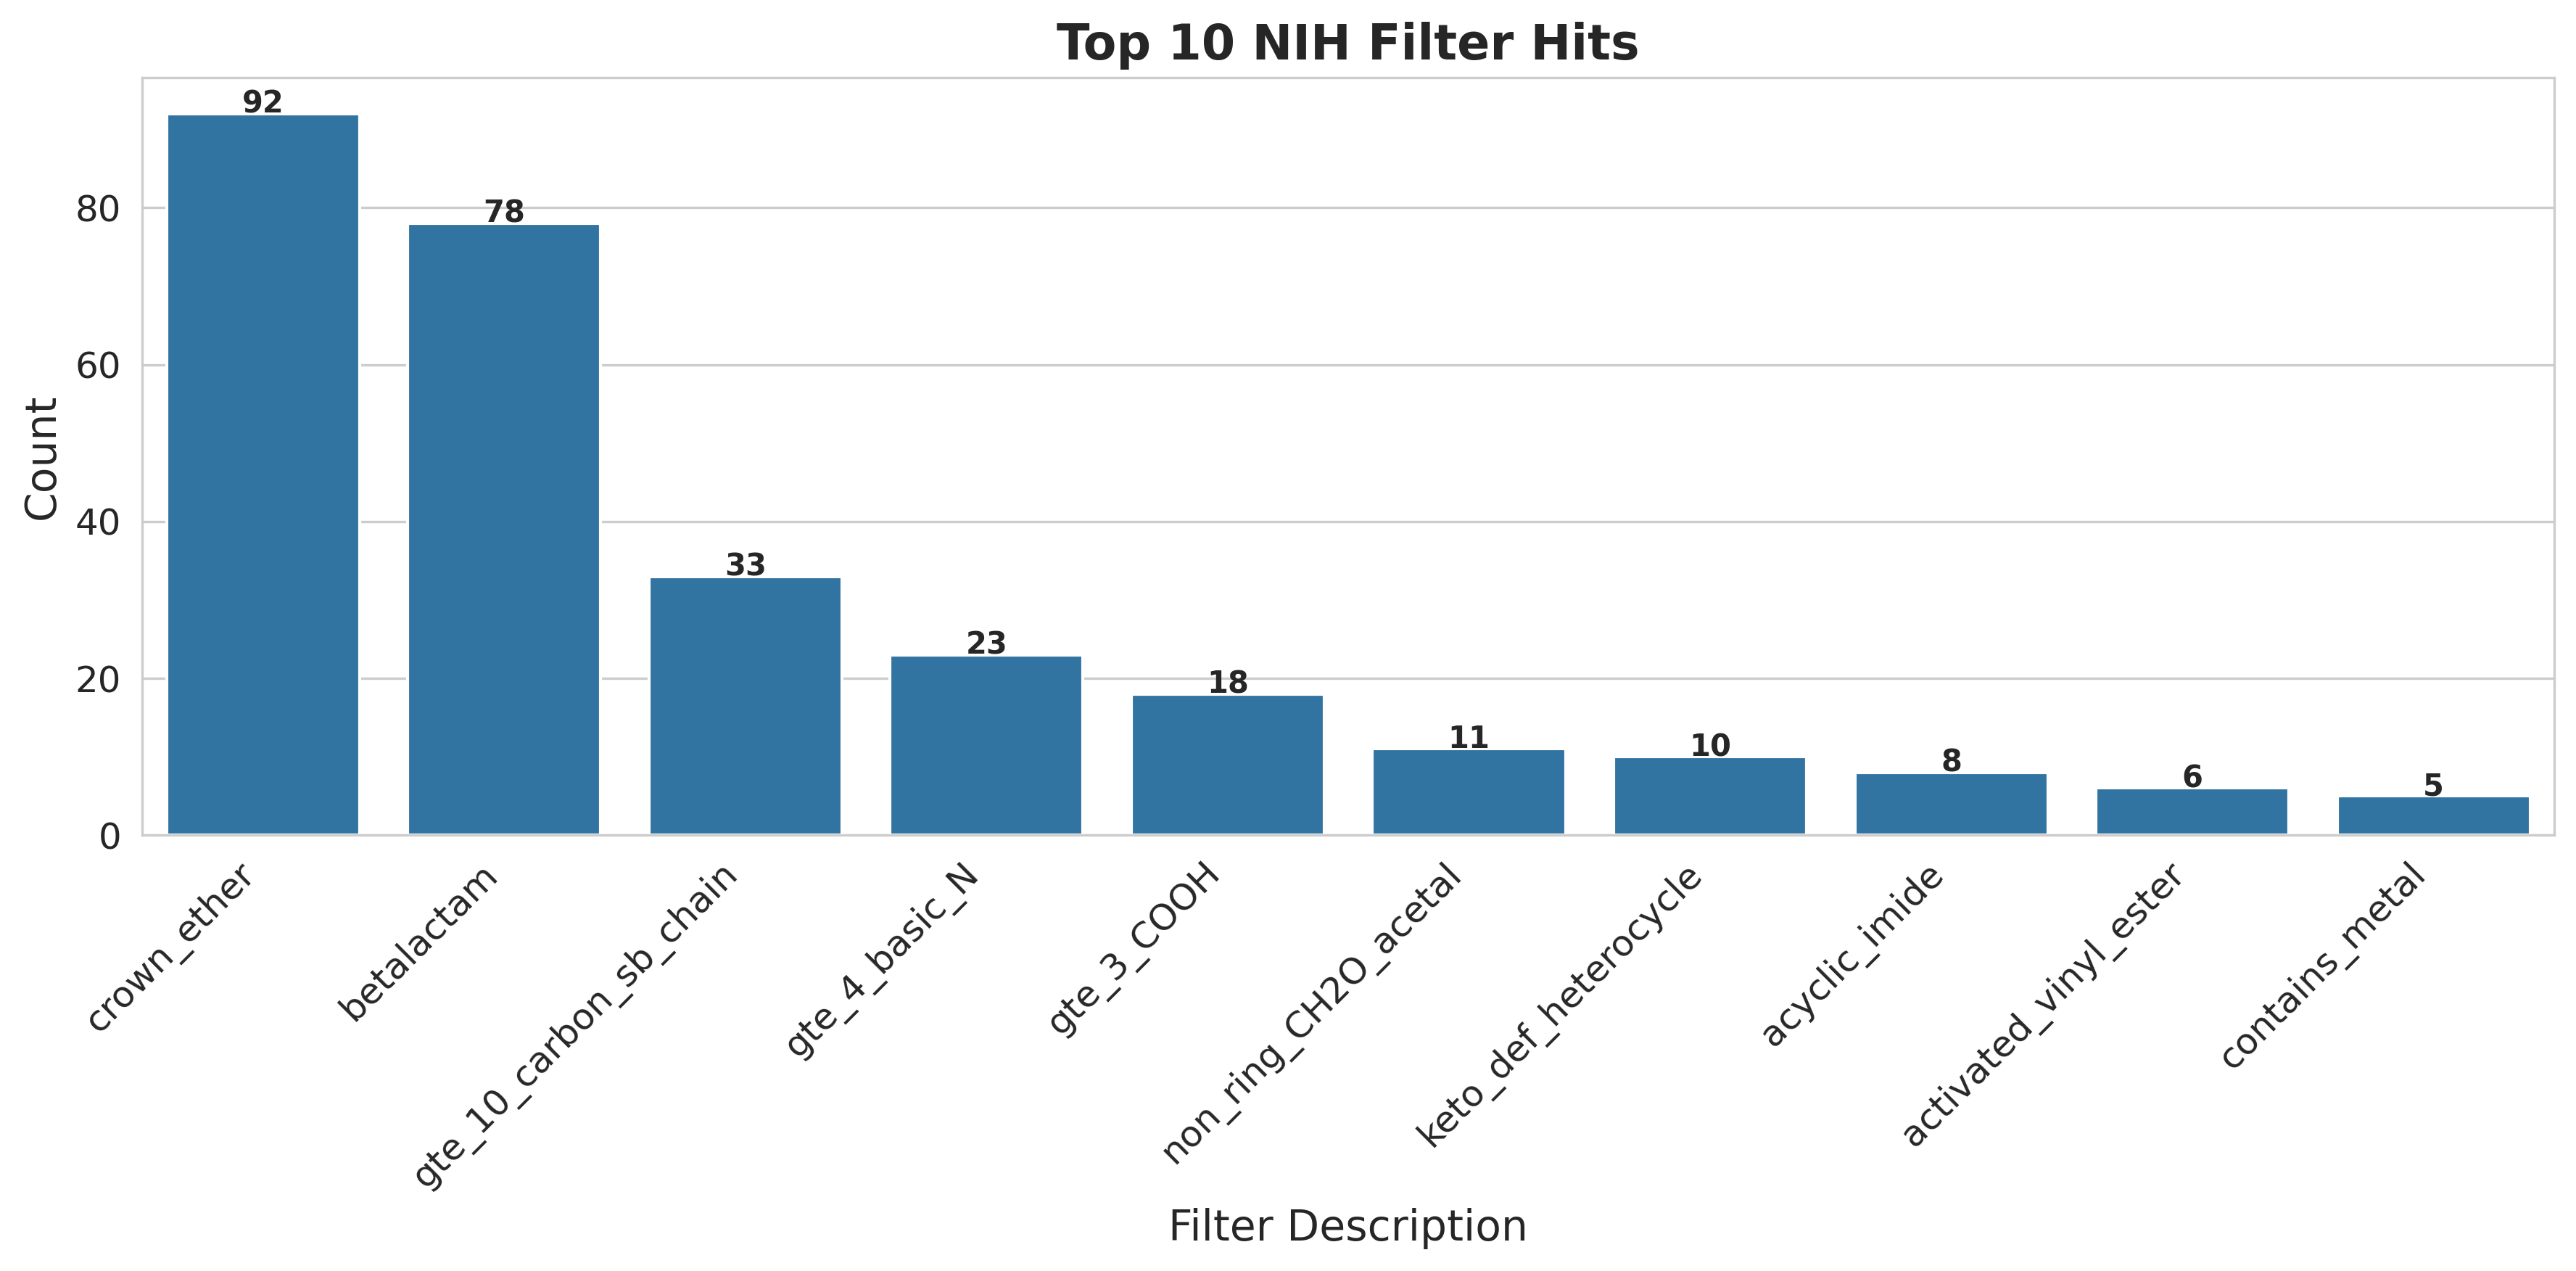

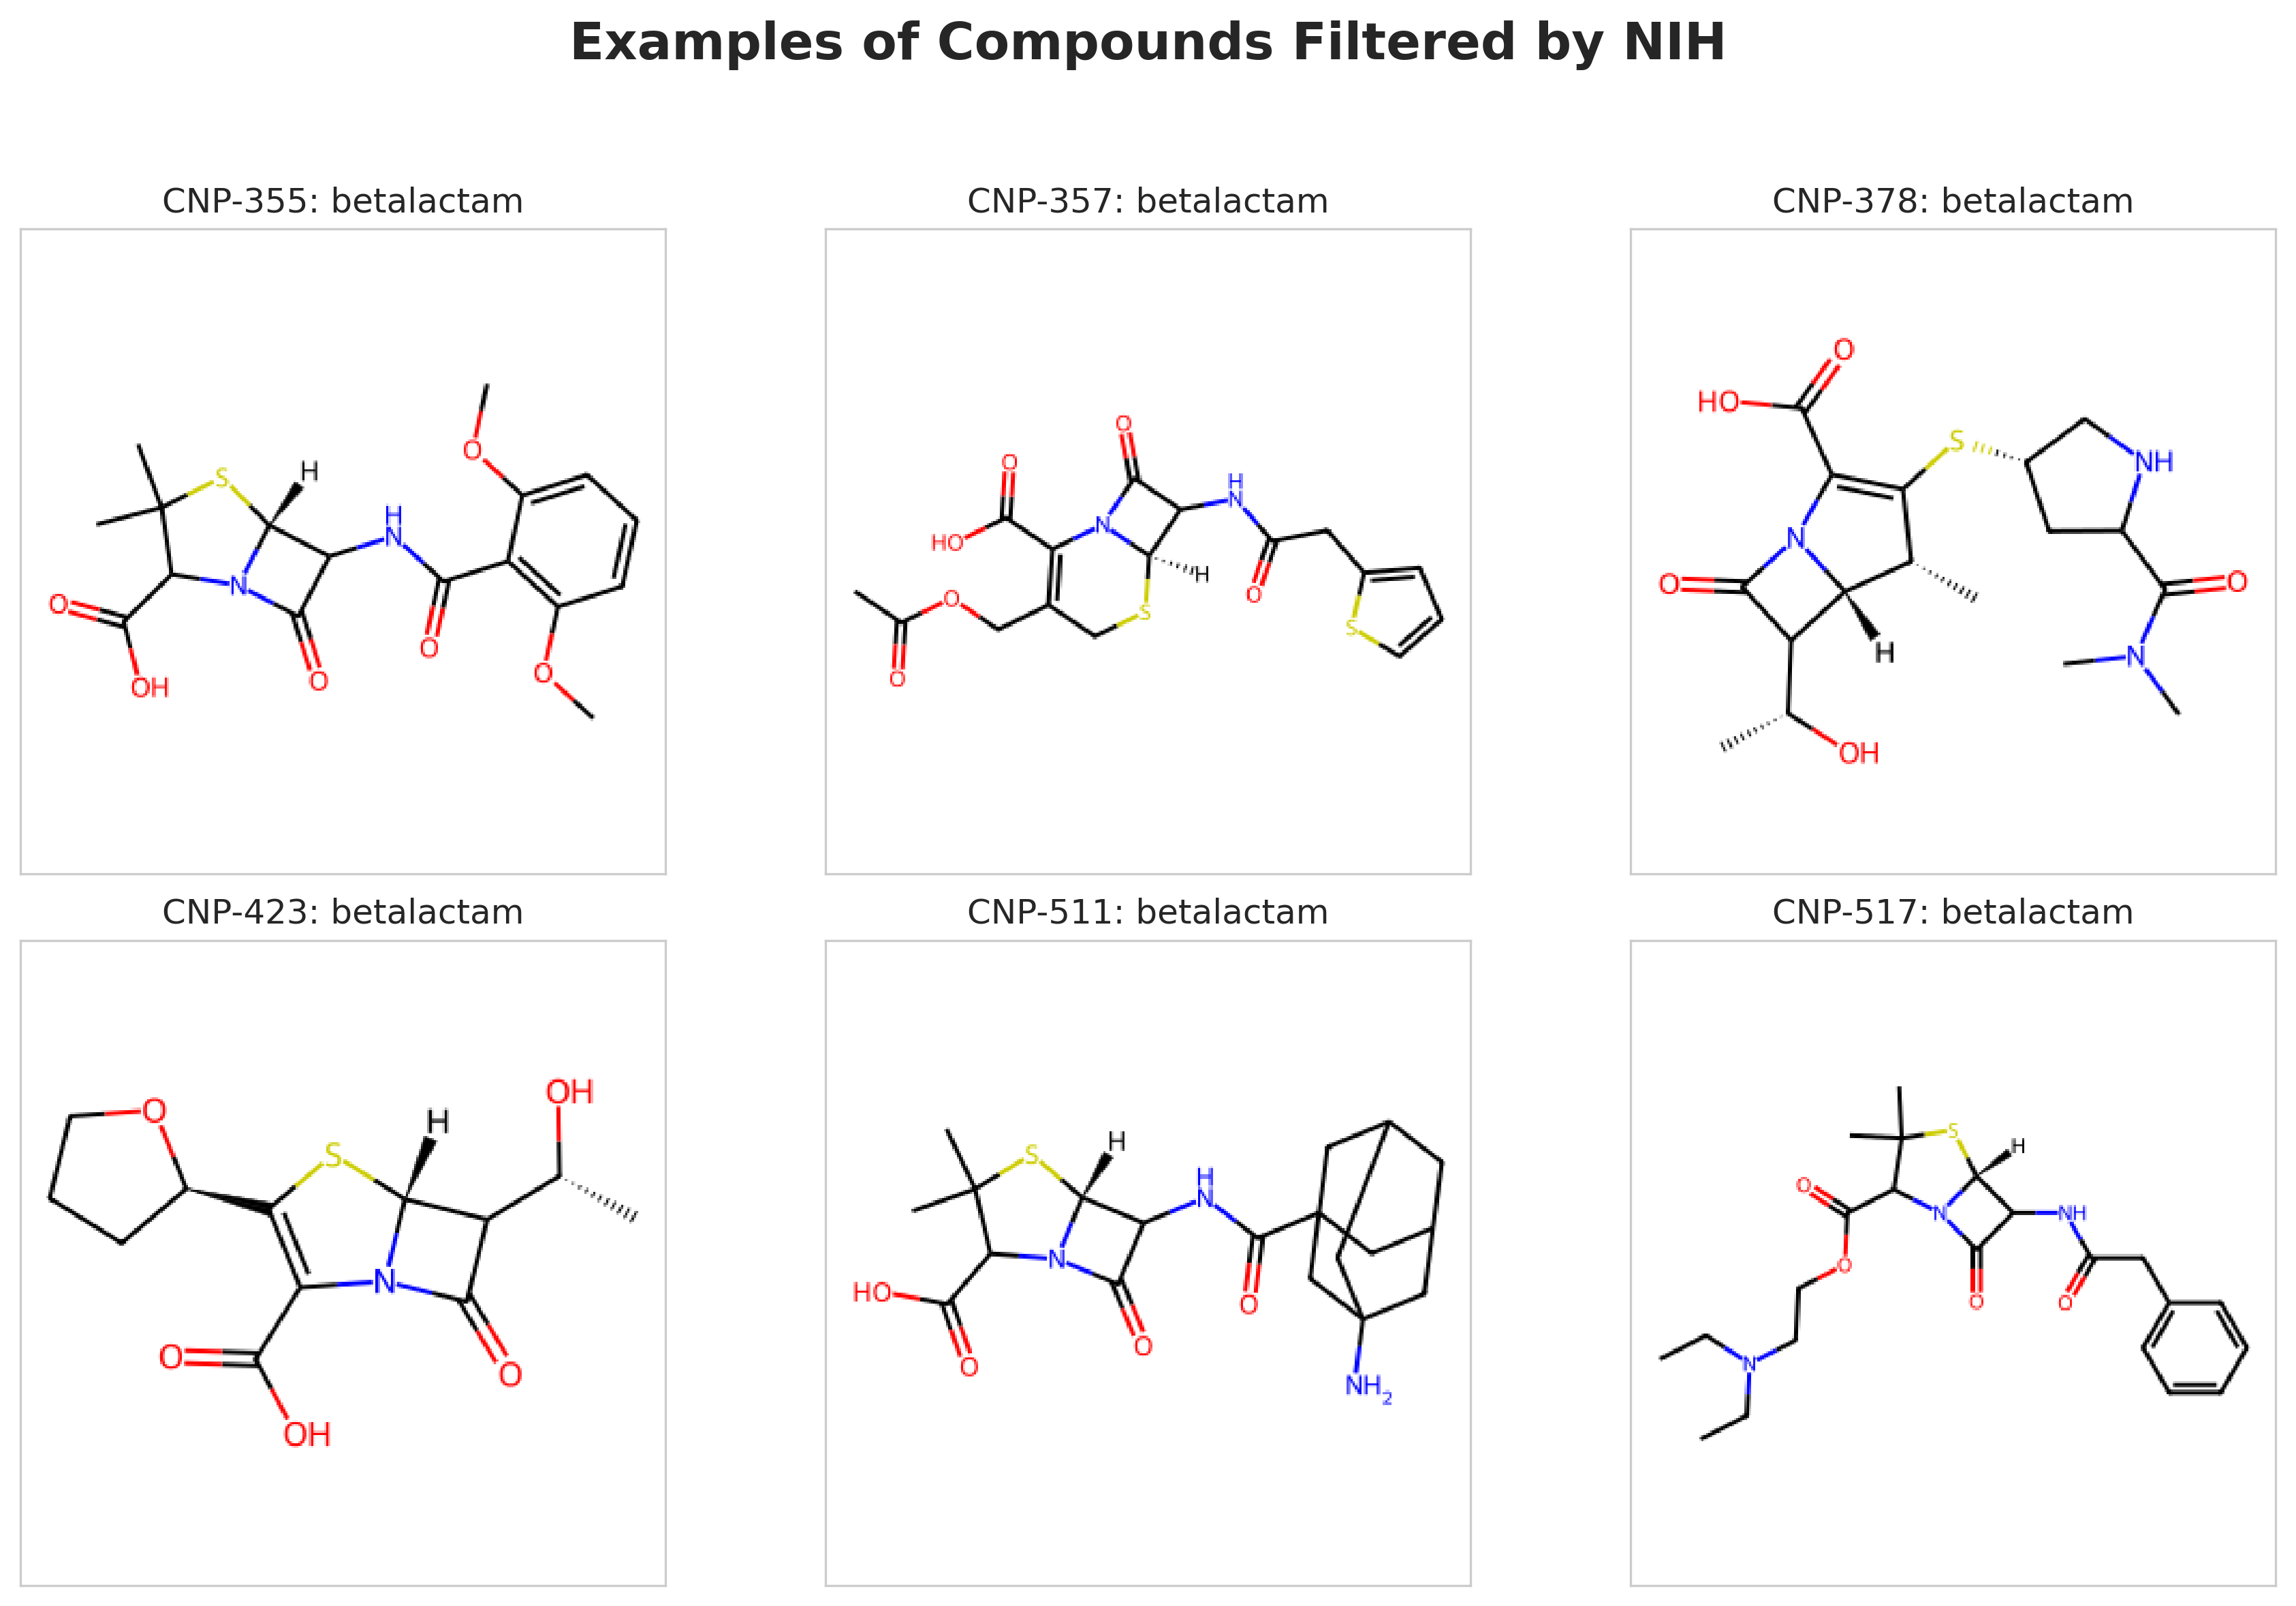



STEP 3: Filtering for PAINS


Checking for PAINS:   0%|          | 0/33995 [00:00<?, ?it/s]


Number of compounds with PAINS: 733
Number of compounds without PAINS: 33262

Visualizing examples of compounds filtered by PAINS:


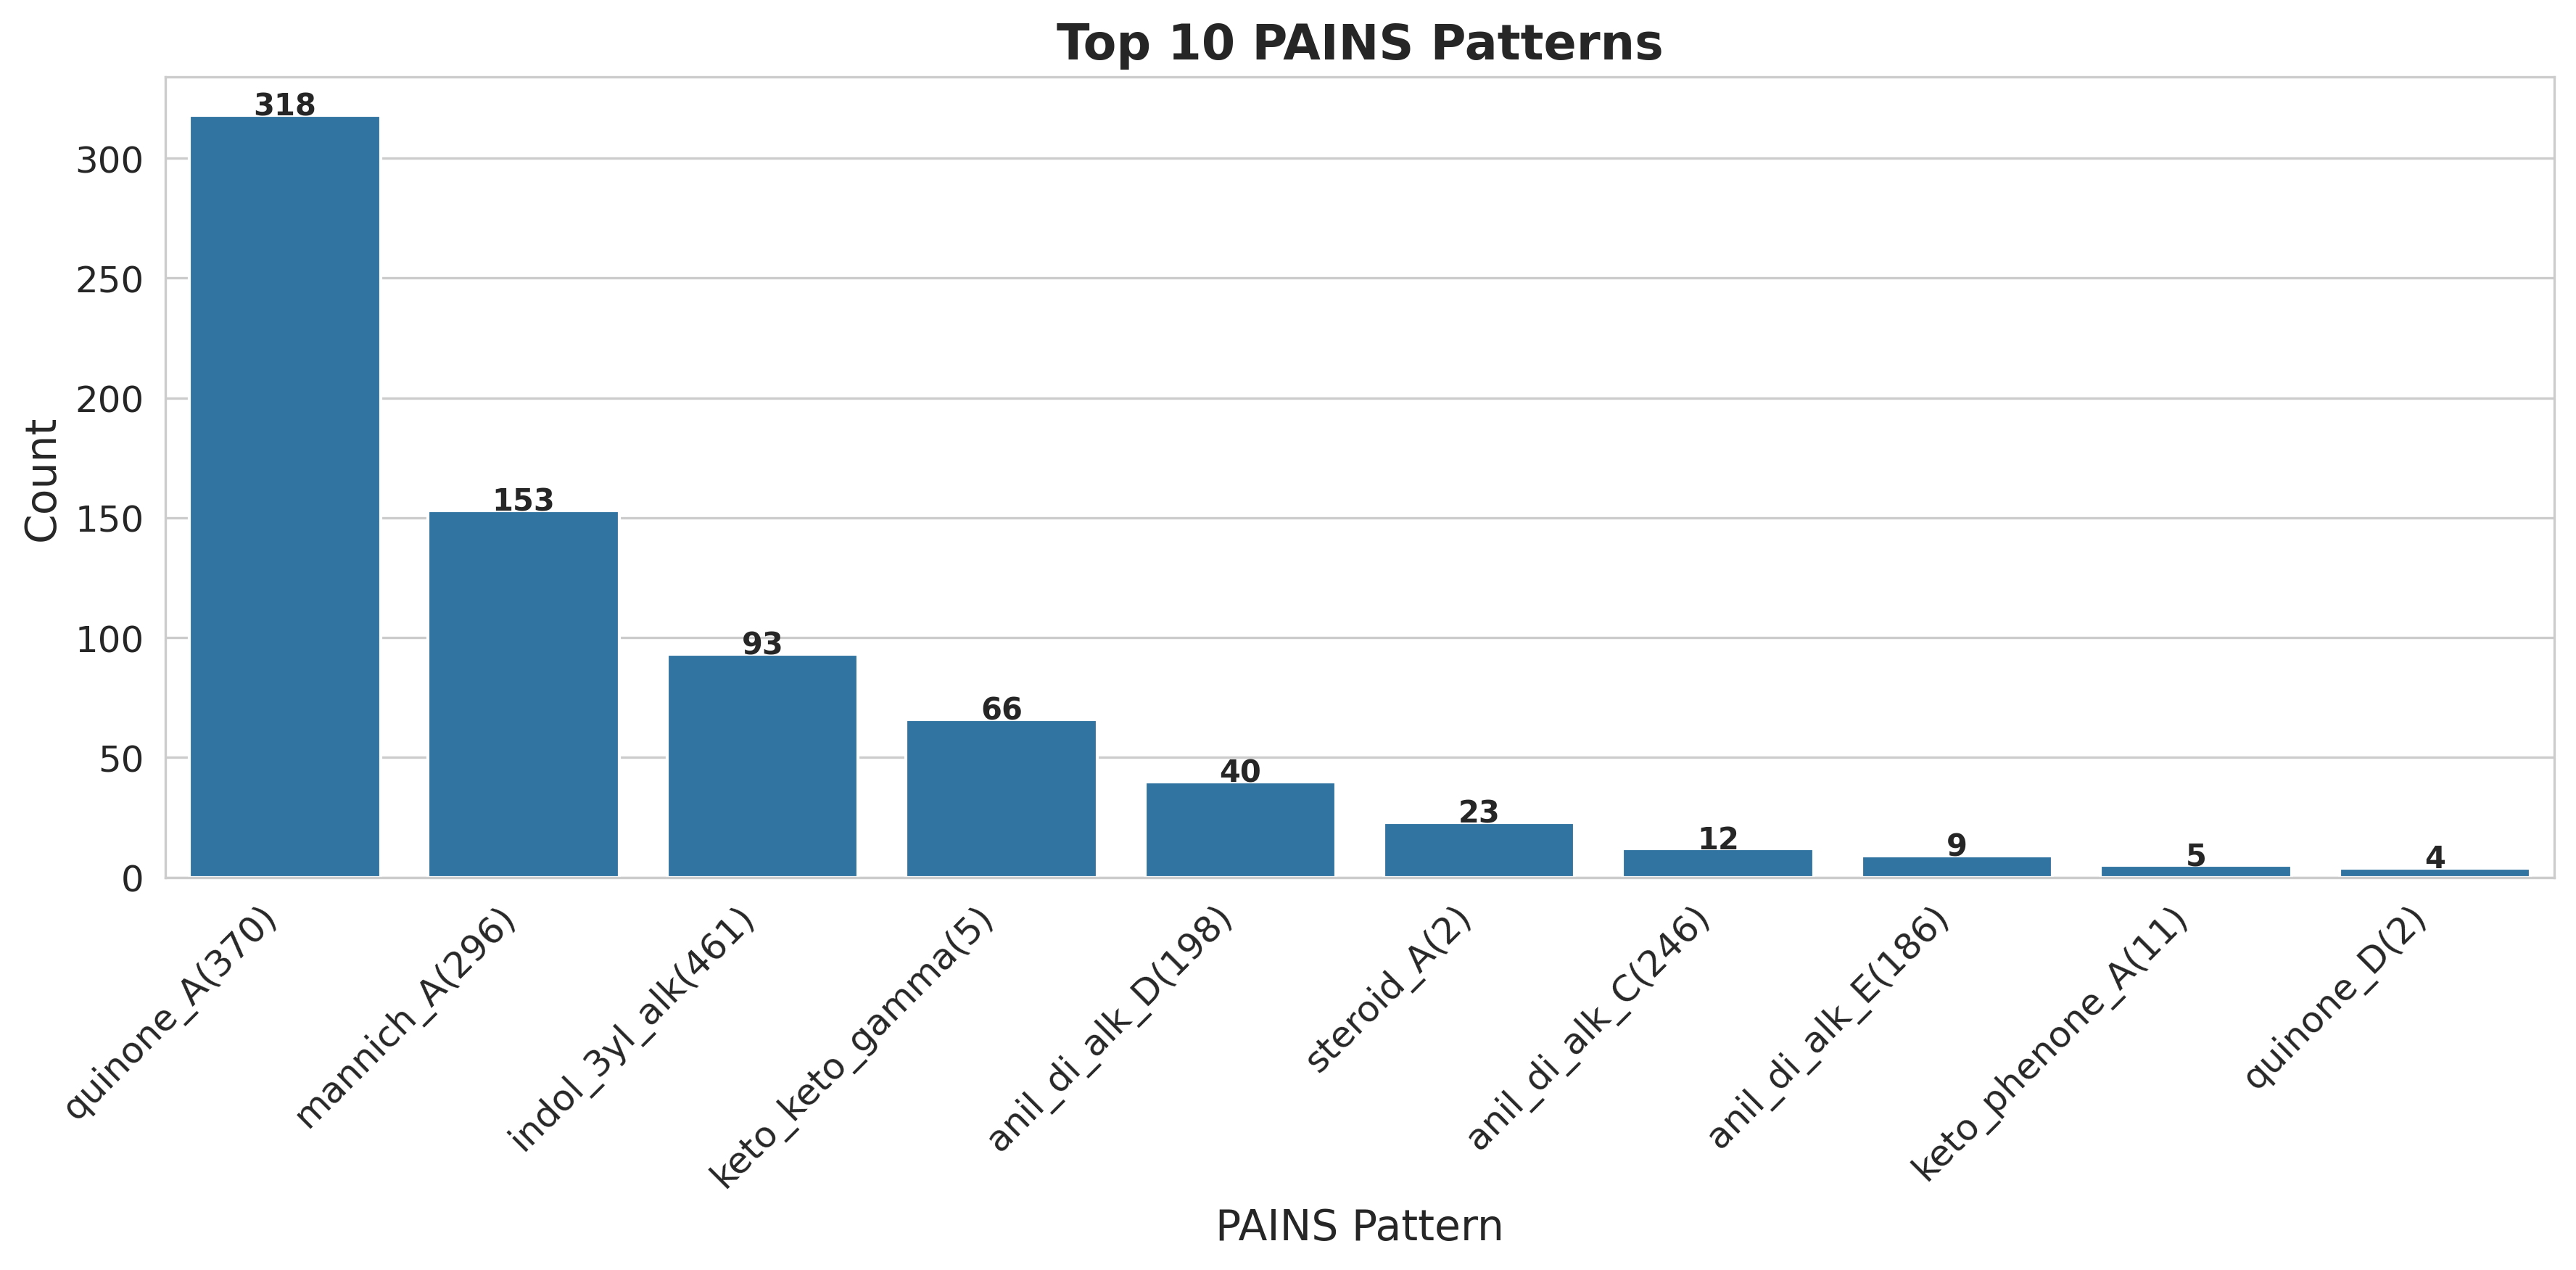

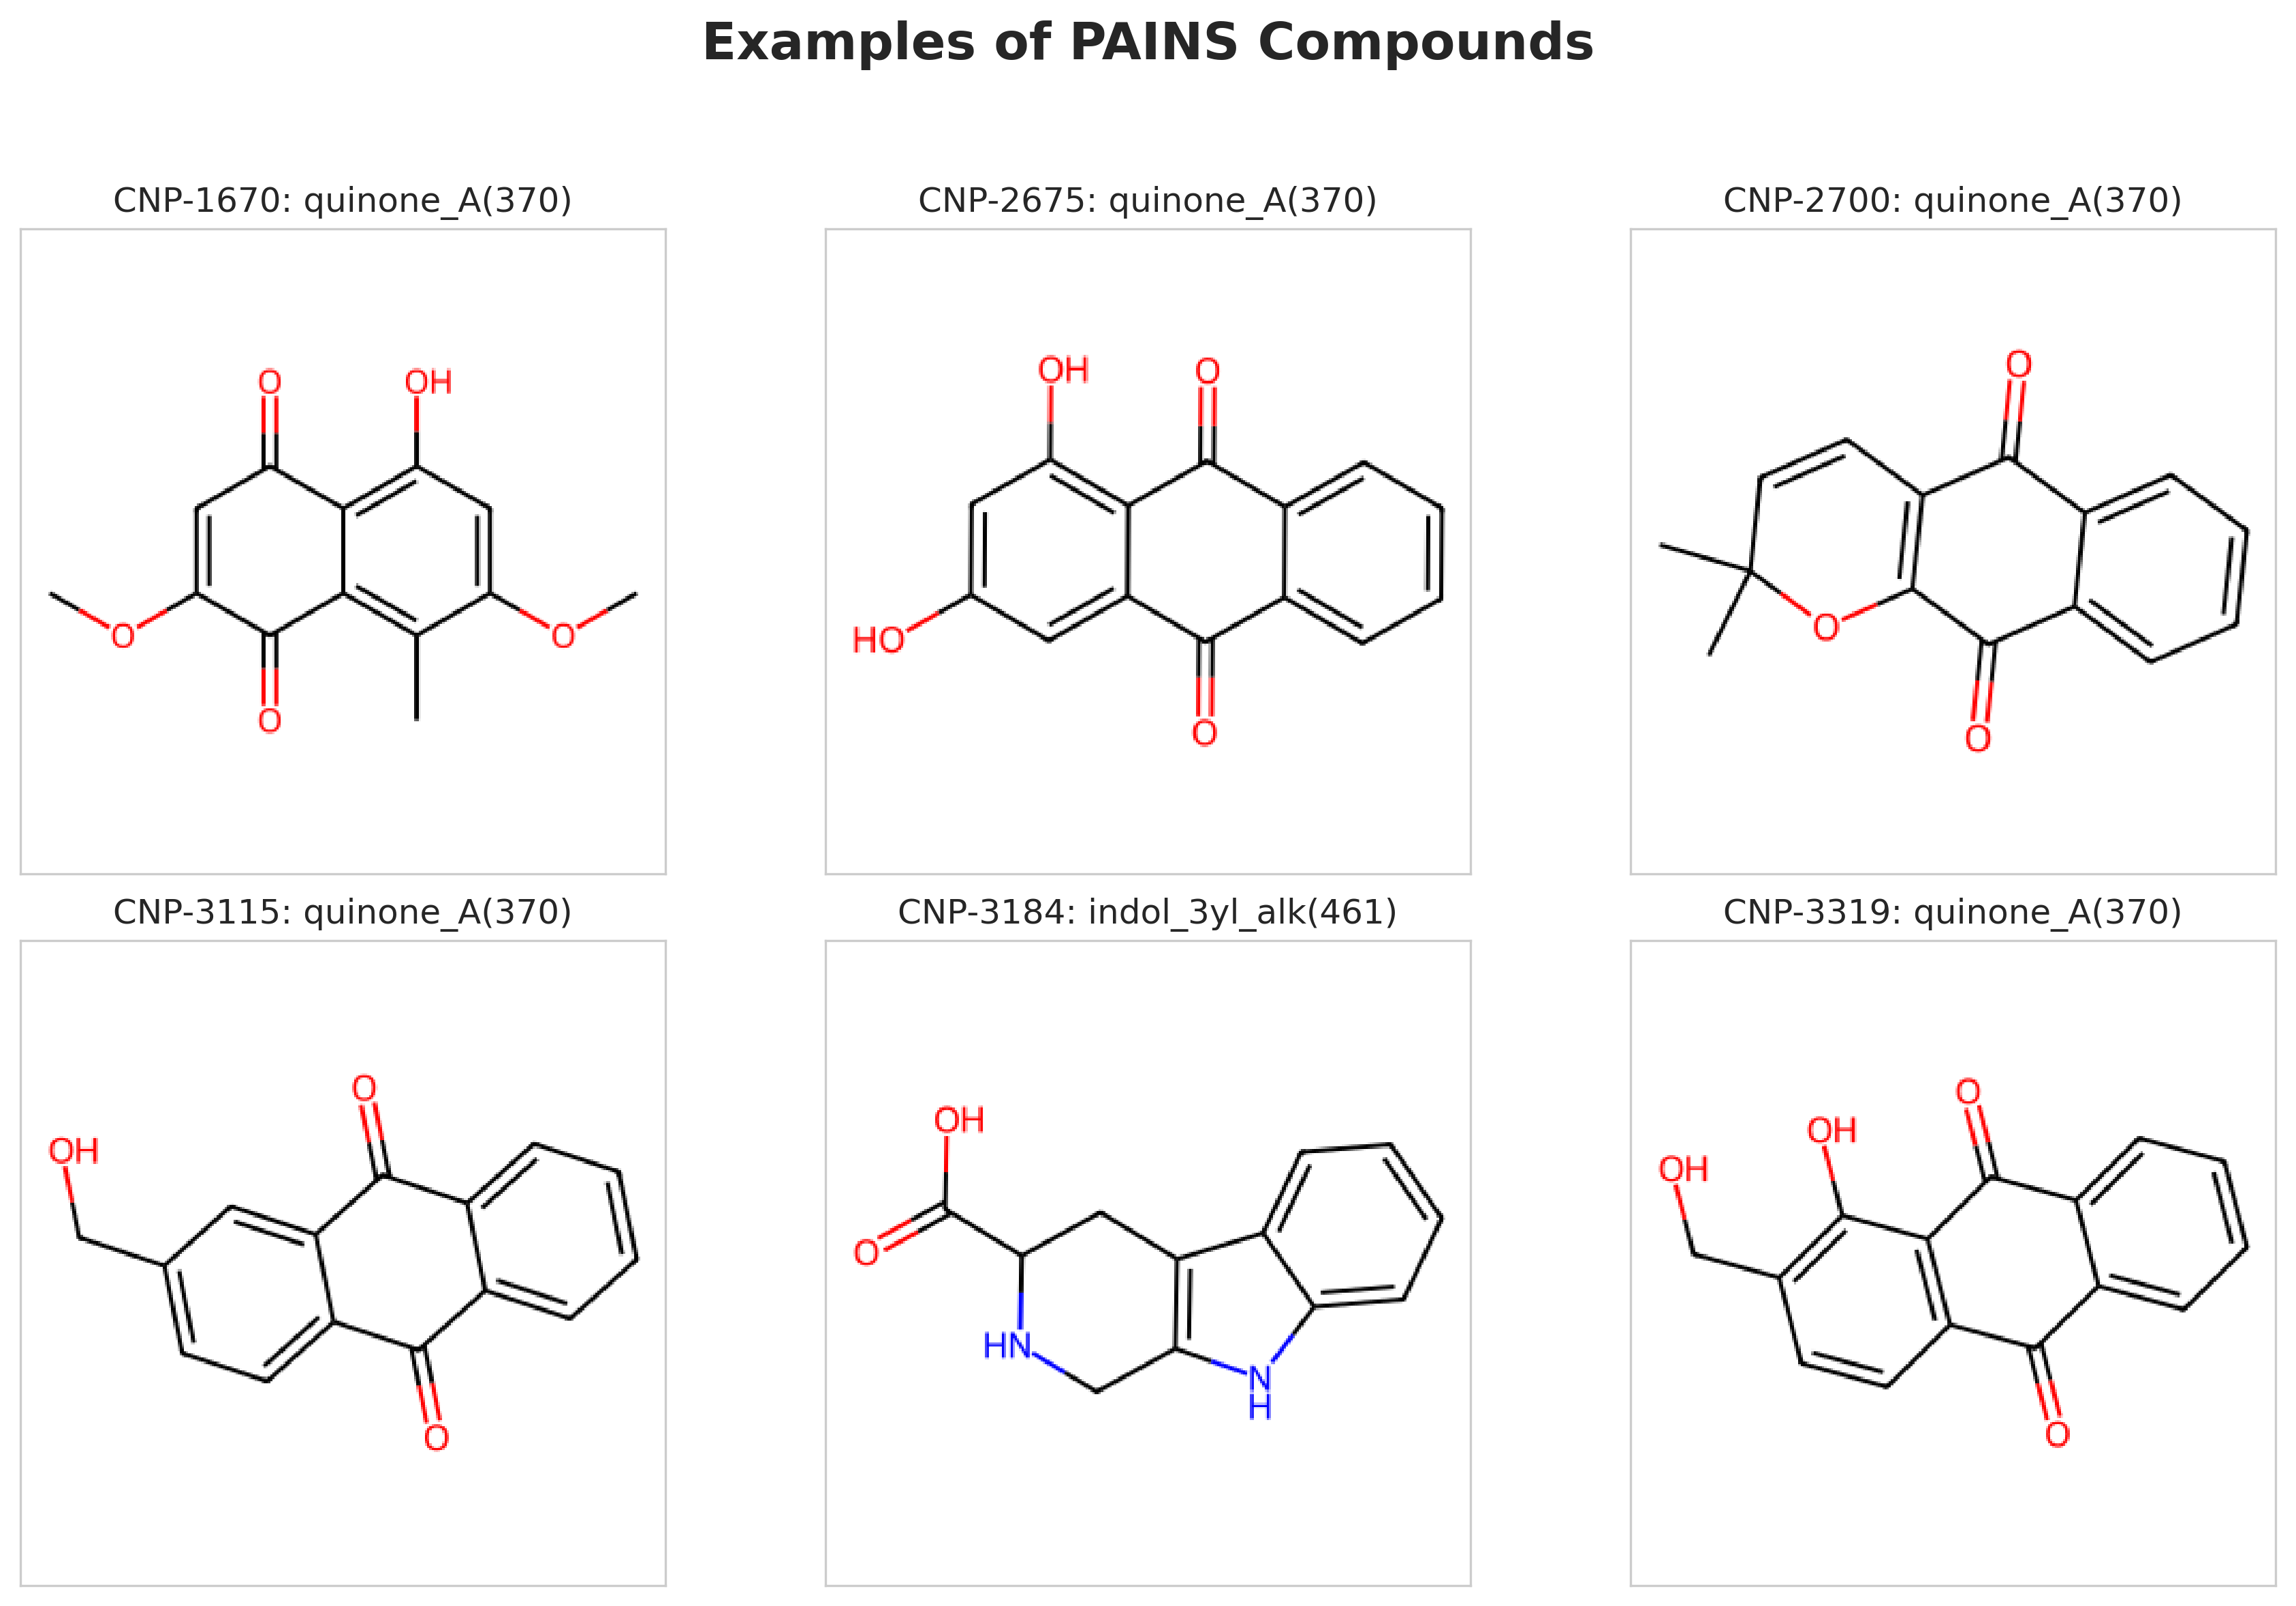



SUMMARY: Medicinal Chemistry Filters Results

Original dataset: 84059 compounds

Filtering steps:
- Brenk: Removed 49765 compounds (59.20%), 34294 remaining
- NIH: Removed 299 compounds (0.87%), 33995 remaining
- PAINS: Removed 733 compounds (2.16%), 33262 remaining

Final dataset: 33262 compounds (39.57% of original)


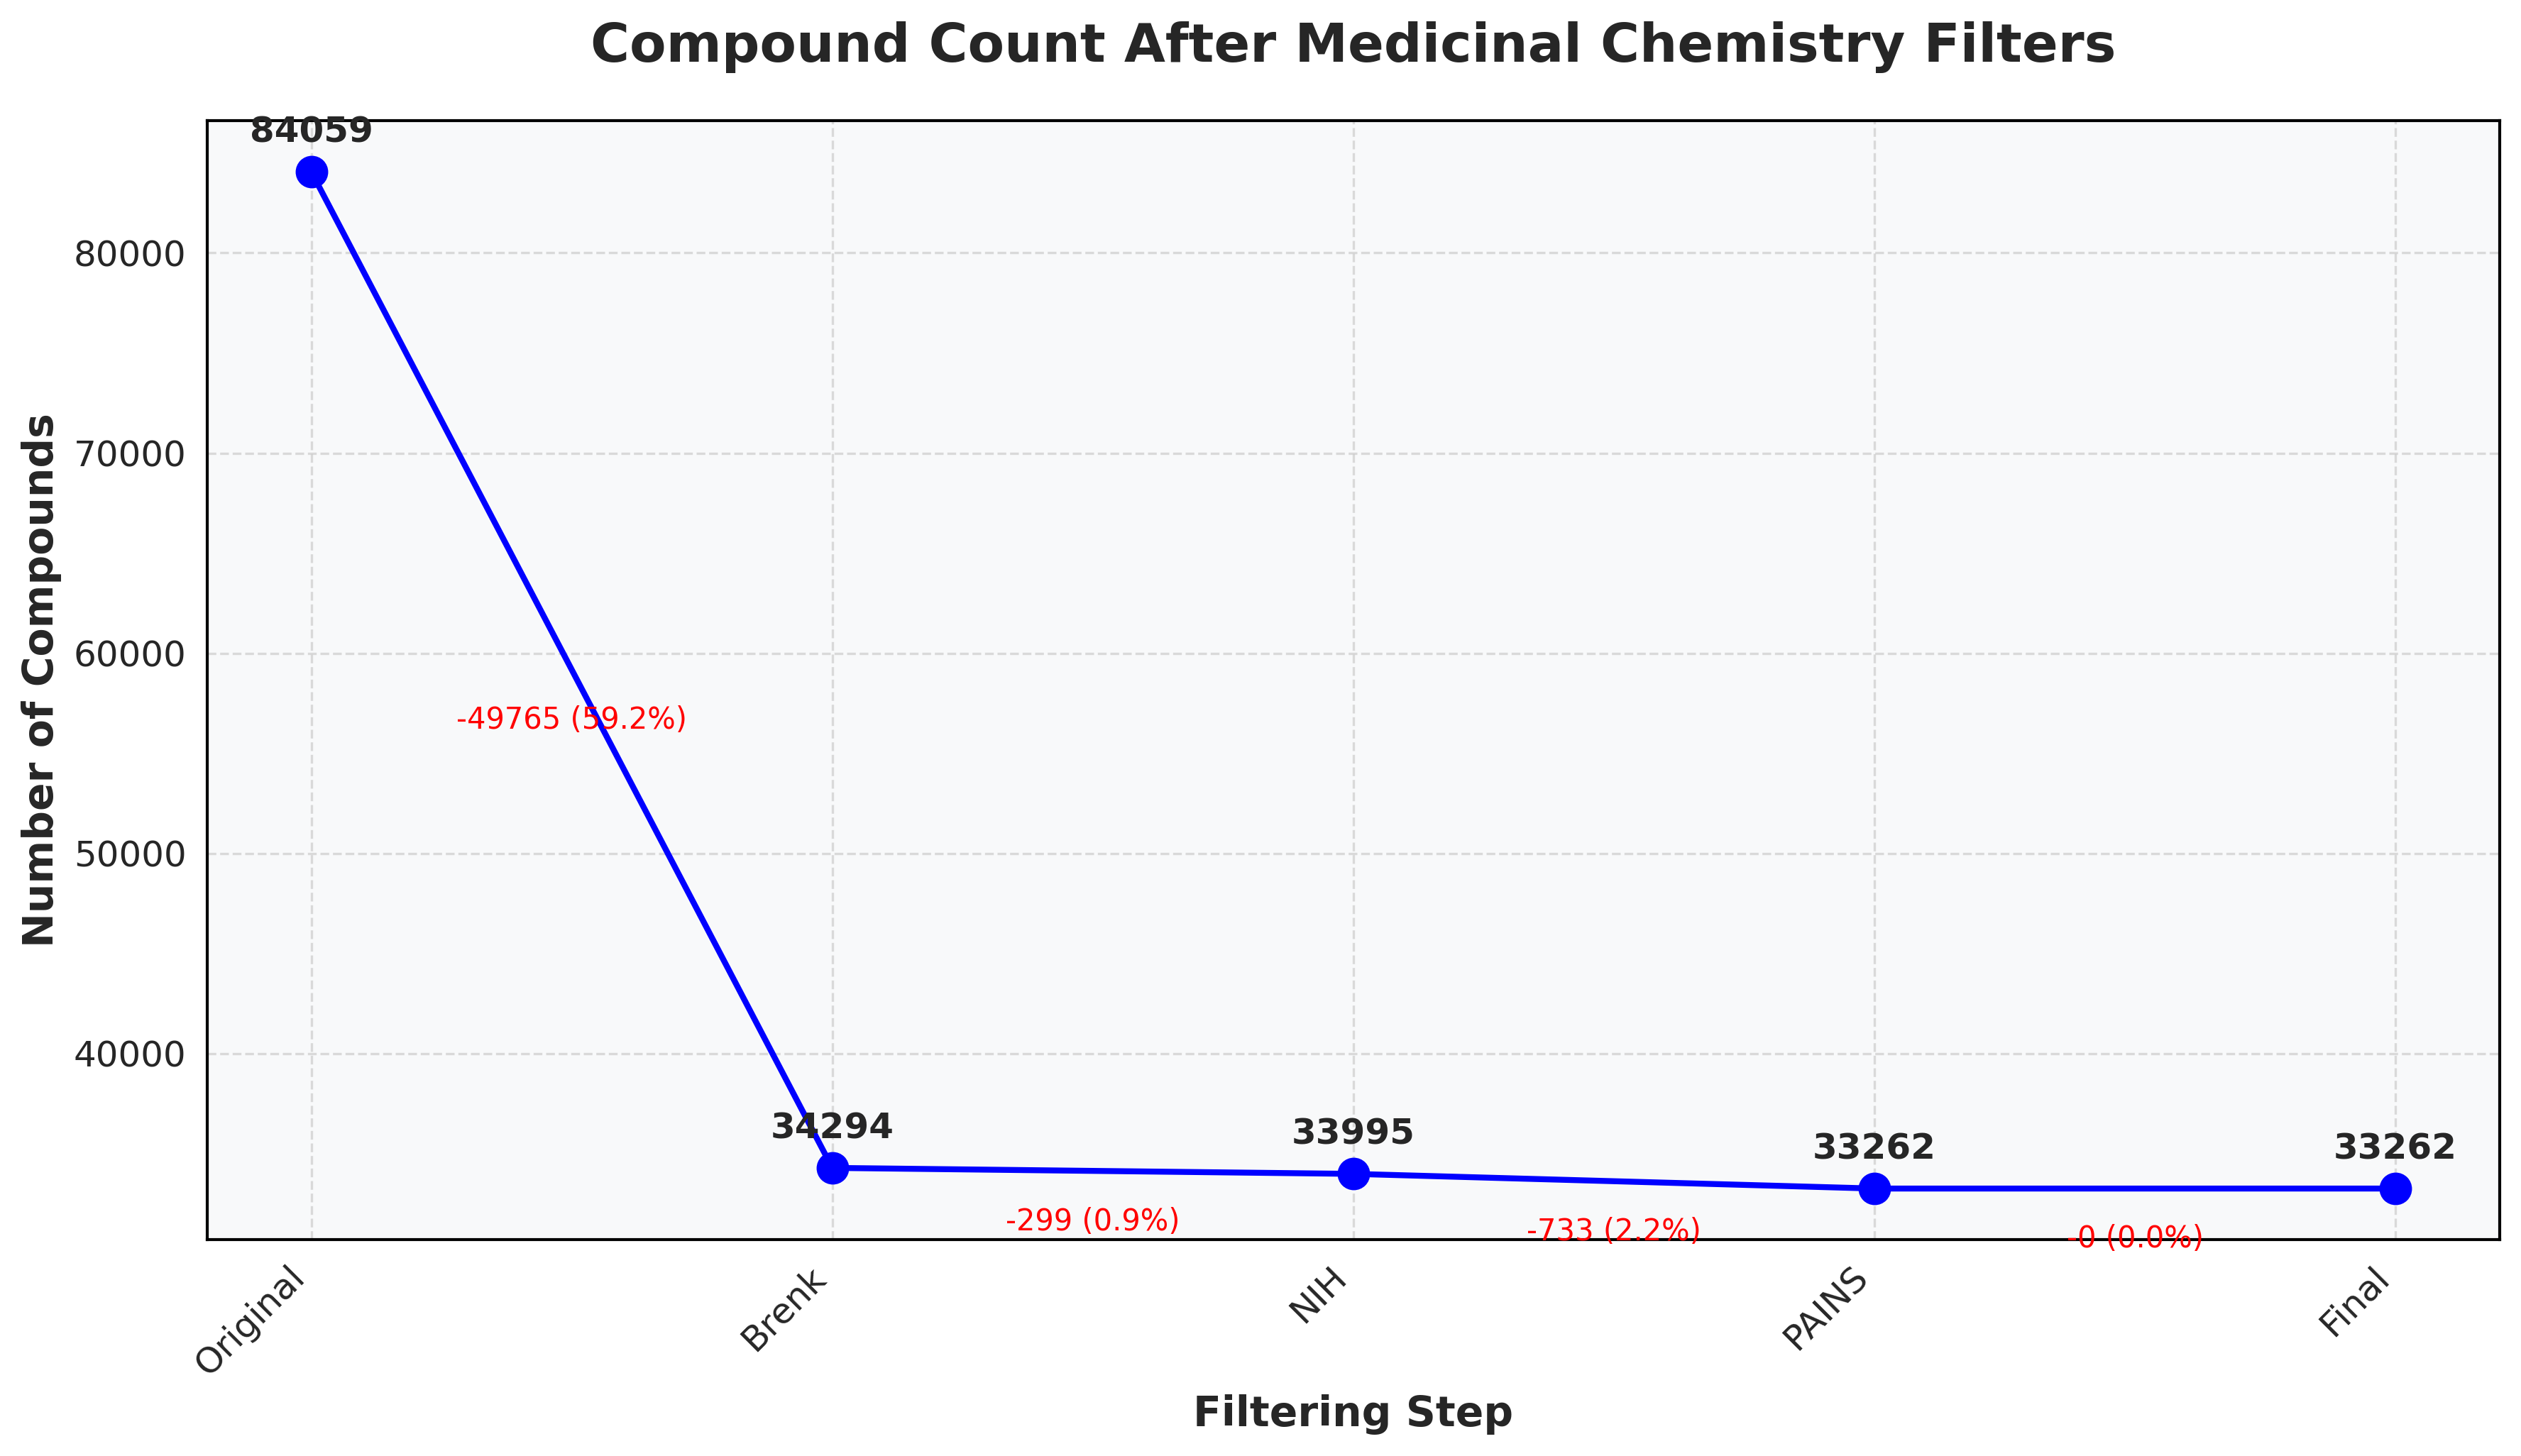

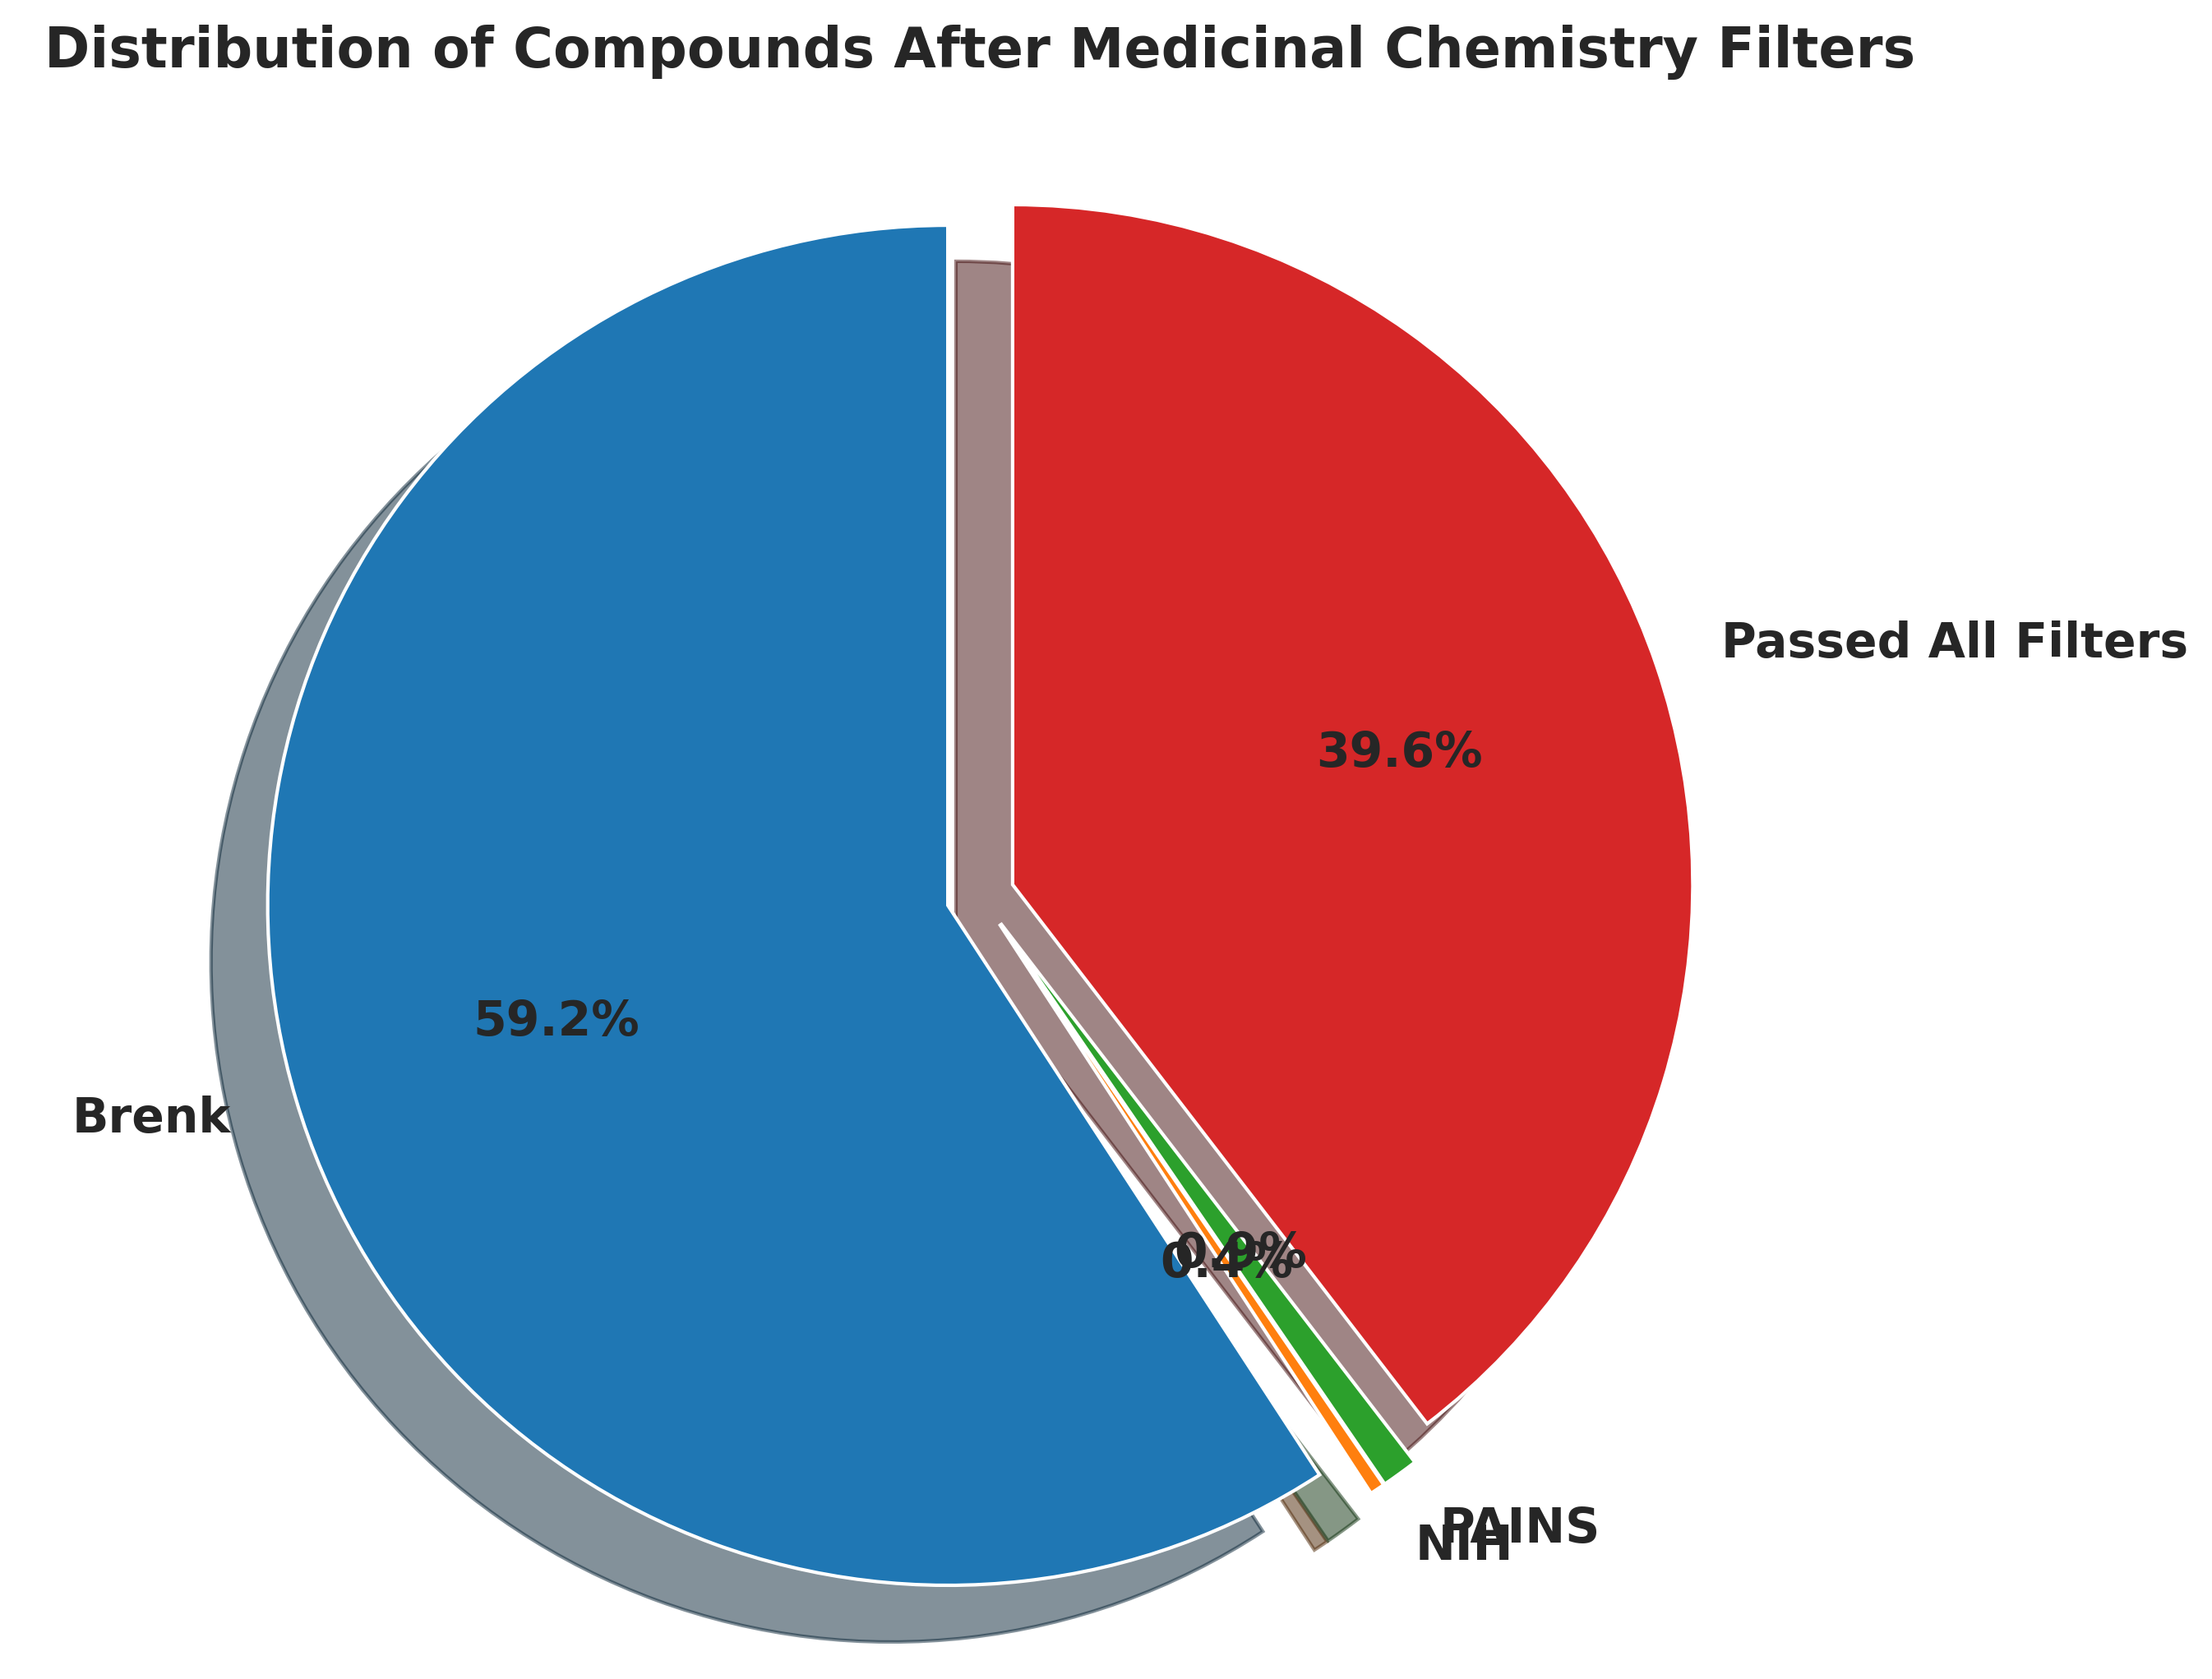



SAVING AND DOWNLOADING RESULTS

Saved 33262 filtered compounds to /content/filtered_compounds/med_chem_filtered_compounds.csv

Preparing filtered compounds for download...

Created zip file with all results: /content/med_chem_filter_results.zip


/usr/lib/python3.11/zipfile.py:1567: UserWarning: Duplicate name: 'med_chem_filtered_compounds.csv'
  return self._open_to_write(zinfo, force_zip64=force_zip64)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


BRENK,_NIH,_and_PAINS_Filters

You can find all output files in the '/content/filtered_compounds/' directory.
The filtered compounds and a zip file with all results have been downloaded to your computer.


In [4]:
# @title Final_BRENK,_NIH,_and_PAINS_Filters
# =============================================
# Medicinal Chemistry Filters: BRENK, NIH, and PAINS
# For Professional Drug Discovery Applications
# =============================================

# Install required packages
import sys
!pip install rdkit-pypi tqdm seaborn ipywidgets -q

import os
import io
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# RDKit imports
from rdkit import Chem
from rdkit.Chem import Draw, PandasTools, AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

# Set publication-quality plot style
sns.set_style("whitegrid")  # Updated from deprecated 'seaborn-whitegrid'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 18

# Create output directory
output_dir = Path('/content/filtered_compounds')
output_dir.mkdir(exist_ok=True)

# =============================================
# Helper Functions
# =============================================

def visualize_molecules(molecules, labels, title, n_cols=3, mol_size=(300, 300),
                        figsize=(12, 8), highlight_atoms=None):
    """
    Visualize a list of molecules in a grid with labels

    Parameters:
        molecules (list): List of RDKit molecules
        labels (list): List of labels for each molecule
        title (str): Title for the visualization
        n_cols (int): Number of columns in the grid
        mol_size (tuple): Size of each molecule image
        figsize (tuple): Figure size
        highlight_atoms (list): List of atom indices to highlight for each molecule
    """
    if not molecules:
        print(f"No molecules to visualize for: {title}")
        return

    n_mols = len(molecules)
    n_rows = (n_mols + n_cols - 1) // n_cols

    # Create figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    fig.suptitle(title, fontsize=18, fontweight='bold')

    # Ensure axes is always a 2D array
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1 or n_cols == 1:
        axes = axes.reshape(n_rows, n_cols)

    # Draw molecules
    for i in range(n_rows):
        for j in range(n_cols):
            idx = i * n_cols + j
            if idx < n_mols:
                mol = molecules[idx]
                label = labels[idx]

                # Convert mol to image and display
                img = Draw.MolToImage(mol, size=mol_size)
                axes[i, j].imshow(img)
                axes[i, j].set_title(label, fontsize=12)

            # Remove axis ticks
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])

            # Hide empty subplots
            if idx >= n_mols:
                axes[i, j].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

def create_filter_summary_plot(filter_stages, counts, title="Compound Count After Each Filtering Step"):
    """Create a summary plot of filtering steps"""
    fig, ax = plt.subplots(figsize=(12, 7))

    # Create x positions for the plot (0, 1, 2, ...)
    x_positions = np.arange(len(filter_stages))

    # Plot the data
    ax.plot(x_positions, counts, 'bo-', markersize=10, linewidth=2)

    # Add data labels
    for i, (x, y) in enumerate(zip(x_positions, counts)):
        ax.annotate(f"{y}", (x, y), textcoords="offset points",
                   xytext=(0, 10), ha='center', fontsize=12, fontweight='bold')

    # Add percentage labels for reduction
    for i in range(1, len(counts)):
        reduction = counts[i-1] - counts[i]
        percent = (reduction / counts[i-1]) * 100
        midpoint_y = (counts[i-1] + counts[i]) / 2
        # Use x_positions for midpoint calculation instead of filter_stages
        midpoint_x = (x_positions[i-1] + x_positions[i]) / 2
        ax.annotate(f"-{reduction} ({percent:.1f}%)",
                   (midpoint_x, midpoint_y),
                   textcoords="offset points", xytext=(0, -20),
                   ha='center', fontsize=10, color='red')

    # Customize the plot
    ax.set_title(title, fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('Filtering Step', fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Compounds', fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.7)

    # Set the x-tick positions and labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels(filter_stages, rotation=45, ha='right')

    # Add a subtle background color
    ax.set_facecolor('#f8f9fa')

    # Add a box around the plot
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

    plt.tight_layout()
    return fig

# =============================================
# Data Input Section
# =============================================
print("\n" + "="*80)
print("MEDICINAL CHEMISTRY FILTERS: BRENK, NIH, and PAINS")
print("="*80)

print("\nPlease upload your compound file (CSV format)")
print("The file should contain at least 'smiles' and 'compound_name' columns.")
print("If these columns are not present, the script will try to infer them.")

uploaded = files.upload()

if uploaded:
    # Use the first uploaded file as the dataset
    filename = list(uploaded.keys())[0]
    print(f"Using uploaded file: {filename}")

    # Read the data
    compounds_data = pd.read_csv(io.BytesIO(uploaded[filename]))

    # Check if required columns exist
    required_cols = ['smiles', 'compound_name']
    missing_cols = [col for col in compounds_data.columns if col.lower() not in required_cols]

    if len(compounds_data.columns) < 2:
        print("Error: The uploaded file must contain at least two columns.")
        print("Please ensure your CSV has columns for SMILES and compound names.")
        # You might want to exit or raise an error here if the minimum columns aren't met
    else:
        # Infer column names if standard ones are missing
        smiles_col = None
        name_col = None

        # Prioritize standard names
        if 'smiles' in compounds_data.columns:
            smiles_col = 'smiles'
        elif 'SMILES' in compounds_data.columns:
            smiles_col = 'SMILES'
        elif 'Smiles' in compounds_data.columns:
             smiles_col = 'Smiles'
        elif 'smi' in compounds_data.columns:
            smiles_col = 'smi'
        elif 'SMI' in compounds_data.columns:
            smiles_col = 'SMI'
        elif 'Canonical_Smiles' in compounds_data.columns:
            smiles_col = 'Canonical_Smiles'
        elif 'Canonical_SMILES' in compounds_data.columns:
            smiles_col = 'Canonical_SMILES'


        if 'compound_name' in compounds_data.columns:
            name_col = 'compound_name'
        elif 'ID' in compounds_data.columns:
            name_col = 'ID'
        elif 'Id' in compounds_data.columns:
            name_col = 'Id'
        elif 'id' in compounds_data.columns:
            name_col = 'id'
        elif 'name' in compounds_data.columns:
            name_col = 'name'

        # If standard names are not found, try to infer based on position
        if smiles_col is None:
            smiles_col = compounds_data.columns[1] # Assume second column is smiles
            print(f"Warning: 'smiles' column not found. Using '{smiles_col}' as SMILES.")

        if name_col is None:
             name_col = compounds_data.columns[0] # Assume first column is name
             print(f"Warning: 'compound_name' column not found. Using '{name_col}' as compound name.")

        # Rename columns to standard 'smiles' and 'compound_name'
        if smiles_col != 'smiles':
            compounds_data.rename(columns={smiles_col: 'smiles'}, inplace=True)
            print(f"Renamed '{smiles_col}' to 'smiles'")

        if name_col != 'compound_name':
            compounds_data.rename(columns={name_col: 'compound_name'}, inplace=True)
            print(f"Renamed '{name_col}' to 'compound_name'")


    # Remove any unnamed columns
    unnamed_cols = [col for col in compounds_data.columns if 'Unnamed:' in col]
    if unnamed_cols:
        compounds_data = compounds_data.drop(unnamed_cols, axis=1)
        print(f"Removed {len(unnamed_cols)} unnamed columns: {unnamed_cols}")

    print(f"\nDataset shape: {compounds_data.shape}")
    print("\nFirst 5 rows of data:")
    print(compounds_data.head())

    # Create a copy of the original data to track filtering steps
    original_count = len(compounds_data)
    filtered_data = compounds_data.copy()

    # Add molecule column to the dataframe
    print("\nAdding molecule representations...")
    PandasTools.AddMoleculeColumnToFrame(filtered_data, smilesCol="smiles")

    # Display a few example molecules
    print("\nVisualizing example molecules from the dataset:")
    valid_mols = [mol for mol in filtered_data.head(6).ROMol.tolist() if mol is not None]
    if valid_mols:
        example_mols = valid_mols[:6]
        example_labels = filtered_data.head(len(example_mols))["compound_name"].astype(str).tolist()
        fig = visualize_molecules(example_mols, example_labels, "Example Compounds from Dataset", n_cols=3)
        plt.savefig(output_dir / "example_compounds.png", dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("Warning: No valid molecules found in the first 6 entries. Check your SMILES strings.")

    # Create a tracking dictionary for reporting
    filtering_stats = {
        "Original": len(filtered_data),
        "After Filters": {}
    }

    # =============================================
    # Apply Brenk Filter (FIRST)
    # =============================================
    print("\n\n" + "="*80)
    print("STEP 1: Applying Brenk Filter")
    print("="*80)

    # Initialize the Brenk filter
    brenk_params = FilterCatalogParams()
    brenk_params.AddCatalog(FilterCatalogParams.FilterCatalogs.BRENK)
    brenk_catalog = FilterCatalog(brenk_params)

    # Apply Brenk filter
    brenk_matches = []
    brenk_clean_indices = []
    for index, row in tqdm(filtered_data.iterrows(), total=filtered_data.shape[0], desc="Applying Brenk filter"):
        molecule = row.ROMol
        if molecule is not None:
            entry = brenk_catalog.GetFirstMatch(molecule)
            if entry is not None:
                brenk_matches.append({
                    "compound_name": row["compound_name"],
                    "smiles": row["smiles"],
                    "rdkit_molecule": molecule,
                    "filter_description": entry.GetDescription()
                })
            else:
                brenk_clean_indices.append(index)

    # Save the Brenk matches
    brenk_matches_df = pd.DataFrame(brenk_matches) if brenk_matches else pd.DataFrame()
    if not brenk_matches_df.empty:
        # Drop the RDKit molecule column for saving
        save_df = brenk_matches_df.copy()
        if 'rdkit_molecule' in save_df.columns:
            save_df = save_df.drop('rdkit_molecule', axis=1)
        save_df.to_csv(output_dir / "brenk_filtered_compounds.csv", index=False)

    # Keep only compounds that passed Brenk filter
    filtered_data = filtered_data.loc[brenk_clean_indices]
    filtering_stats["After Filters"]["Brenk"] = len(filtered_data)
    print(f"\nRemoved {len(brenk_matches)} compounds using Brenk filter.")
    print(f"Remaining compounds: {len(filtered_data)}")

    # Visualize some Brenk-filtered compounds if any were found
    if brenk_matches:
        try:
            print("\nVisualizing examples of compounds filtered by Brenk:")
            brenk_df = pd.DataFrame(brenk_matches)

            # Group by filter description
            filter_counts = brenk_df['filter_description'].value_counts()

            # Create a bar chart of Brenk filter hits
            plt.figure(figsize=(12, 6))
            ax = sns.barplot(x=filter_counts.index[:10], y=filter_counts.values[:10])
            plt.title('Top 10 Brenk Filter Hits', fontsize=16, fontweight='bold')
            plt.xlabel('Filter Description', fontsize=14)
            plt.ylabel('Count', fontsize=14)
            plt.xticks(rotation=45, ha='right')

            # Add count labels on top of bars
            for i, v in enumerate(filter_counts.values[:10]):
                ax.text(i, v + 0.1, str(v), ha='center', fontsize=10, fontweight='bold')

            plt.tight_layout()
            plt.savefig(output_dir / "brenk_filter_hits.png", dpi=300, bbox_inches='tight')
            plt.show()

            # Visualize example molecules
            brenk_mols = [row["rdkit_molecule"] for _, row in brenk_df.head(6).iterrows() if row["rdkit_molecule"] is not None]
            if brenk_mols:
                brenk_labels = [f"{row['compound_name']}: {row['filter_description']}" for _, row in brenk_df.head(len(brenk_mols)).iterrows()]
                fig = visualize_molecules(brenk_mols, brenk_labels, "Examples of Compounds Filtered by Brenk", n_cols=3)
                plt.savefig(output_dir / "brenk_filtered_examples.png", dpi=300, bbox_inches='tight')
                plt.show()
            else:
                print("No valid molecules to visualize.")
        except Exception as e:
            print(f"Error visualizing Brenk-filtered compounds: {e}")

    # =============================================
    # Apply NIH Filter (SECOND)
    # =============================================
    print("\n\n" + "="*80)
    print("STEP 2: Applying NIH Filter")
    print("="*80)

    # Initialize NIH filter
    nih_params = FilterCatalogParams()
    nih_params.AddCatalog(FilterCatalogParams.FilterCatalogs.NIH)
    nih_catalog = FilterCatalog(nih_params)

    # Apply NIH filter
    nih_matches = []
    nih_clean_indices = []
    for index, row in tqdm(filtered_data.iterrows(), total=filtered_data.shape[0], desc="Applying NIH filter"):
        molecule = row.ROMol
        if molecule is not None:
            entry = nih_catalog.GetFirstMatch(molecule)
            if entry is not None:
                nih_matches.append({
                    "compound_name": row["compound_name"],
                    "smiles": row["smiles"],
                    "rdkit_molecule": molecule,
                    "filter_description": entry.GetDescription()
                })
            else:
                nih_clean_indices.append(index)

    # Save the NIH matches
    nih_matches_df = pd.DataFrame(nih_matches) if nih_matches else pd.DataFrame()
    if not nih_matches_df.empty:
        # Drop the RDKit molecule column for saving
        save_df = nih_matches_df.copy()
        if 'rdkit_molecule' in save_df.columns:
            save_df = save_df.drop('rdkit_molecule', axis=1)
        save_df.to_csv(output_dir / "nih_filtered_compounds.csv", index=False)

    # Keep only compounds that passed NIH filter
    filtered_data = filtered_data.loc[nih_clean_indices]
    filtering_stats["After Filters"]["NIH"] = len(filtered_data)
    print(f"\nRemoved {len(nih_matches)} compounds using NIH filter.")
    print(f"Remaining compounds: {len(filtered_data)}")

    # Visualize some NIH-filtered compounds if any were found
    if nih_matches:
        try:
            print("\nVisualizing examples of compounds filtered by NIH:")
            nih_df = pd.DataFrame(nih_matches)

            # Group by filter description
            filter_counts = nih_df['filter_description'].value_counts()

            # Create a bar chart of NIH filter hits
            plt.figure(figsize=(12, 6))
            ax = sns.barplot(x=filter_counts.index[:10], y=filter_counts.values[:10])
            plt.title('Top 10 NIH Filter Hits', fontsize=16, fontweight='bold')
            plt.xlabel('Filter Description', fontsize=14)
            plt.ylabel('Count', fontsize=14)
            plt.xticks(rotation=45, ha='right')

            # Add count labels on top of bars
            for i, v in enumerate(filter_counts.values[:10]):
                ax.text(i, v + 0.1, str(v), ha='center', fontsize=10, fontweight='bold')

            plt.tight_layout()
            plt.savefig(output_dir / "nih_filter_hits.png", dpi=300, bbox_inches='tight')
            plt.show()

            # Visualize example molecules
            nih_mols = [row["rdkit_molecule"] for _, row in nih_df.head(6).iterrows() if row["rdkit_molecule"] is not None]
            if nih_mols:
                nih_labels = [f"{row['compound_name']}: {row['filter_description']}" for _, row in nih_df.head(len(nih_mols)).iterrows()]
                fig = visualize_molecules(nih_mols, nih_labels, "Examples of Compounds Filtered by NIH", n_cols=3)
                plt.savefig(output_dir / "nih_filtered_examples.png", dpi=300, bbox_inches='tight')
                plt.show()
            else:
                print("No valid molecules to visualize.")
        except Exception as e:
            print(f"Error visualizing NIH-filtered compounds: {e}")

    # =============================================
    # Filter for PAINS (THIRD)
    # =============================================
    print("\n\n" + "="*80)
    print("STEP 3: Filtering for PAINS")
    print("="*80)

    # Initialize PAINS filter
    pains_params = FilterCatalogParams()
    pains_params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
    pains_catalog = FilterCatalog(pains_params)

    # Search for PAINS
    pains_matches = []
    pains_clean_indices = []
    for index, row in tqdm(filtered_data.iterrows(), total=filtered_data.shape[0], desc="Checking for PAINS"):
        molecule = row.ROMol
        if molecule is not None:
            entry = pains_catalog.GetFirstMatch(molecule)
            if entry is not None:
                pains_matches.append({
                    "compound_name": row["compound_name"],
                    "smiles": row["smiles"],
                    "rdkit_molecule": molecule,
                    "pains": entry.GetDescription()
                })
            else:
                pains_clean_indices.append(index)

    # Create a DataFrame of PAINS matches
    pains_matches_df = pd.DataFrame(pains_matches) if pains_matches else pd.DataFrame()
    if not pains_matches_df.empty:
        # Drop the RDKit molecule column for saving
        save_df = pains_matches_df.copy()
        if 'rdkit_molecule' in save_df.columns:
            save_df = save_df.drop('rdkit_molecule', axis=1)
        save_df.to_csv(output_dir / "pains_compounds.csv", index=False)

    print(f"\nNumber of compounds with PAINS: {len(pains_matches)}")
    filtered_data = filtered_data.loc[pains_clean_indices]
    filtering_stats["After Filters"]["PAINS"] = len(filtered_data)
    print(f"Number of compounds without PAINS: {len(filtered_data)}")

    # Visualize some PAINS compounds if any were found
    if pains_matches:
        try:
            print("\nVisualizing examples of compounds filtered by PAINS:")
            pains_df = pd.DataFrame(pains_matches)

            # Group by PAINS description
            pains_counts = pains_df['pains'].value_counts()

            # Create a bar chart of PAINS hits
            plt.figure(figsize=(12, 6))
            ax = sns.barplot(x=pains_counts.index[:10], y=pains_counts.values[:10])
            plt.title('Top 10 PAINS Patterns', fontsize=16, fontweight='bold')
            plt.xlabel('PAINS Pattern', fontsize=14)
            plt.ylabel('Count', fontsize=14)
            plt.xticks(rotation=45, ha='right')

            # Add count labels on top of bars
            for i, v in enumerate(pains_counts.values[:10]):
                ax.text(i, v + 0.1, str(v), ha='center', fontsize=10, fontweight='bold')

            plt.tight_layout()
            plt.savefig(output_dir / "pains_patterns.png", dpi=300, bbox_inches='tight')
            plt.show()

            # Visualize example molecules
            pains_mols = [row["rdkit_molecule"] for _, row in pains_df.head(6).iterrows() if row["rdkit_molecule"] is not None]
            if pains_mols:
                pains_labels = [f"{row['compound_name']}: {row['pains']}" for _, row in pains_df.head(len(pains_mols)).iterrows()]
                fig = visualize_molecules(pains_mols, pains_labels, "Examples of PAINS Compounds", n_cols=3)
                plt.savefig(output_dir / "pains_examples.png", dpi=300, bbox_inches='tight')
                plt.show()
            else:
                print("No valid molecules to visualize.")
        except Exception as e:
            print(f"Error visualizing PAINS compounds: {e}")

    # =============================================
    # Summary Report
    # =============================================
    print("\n\n" + "="*80)
    print("SUMMARY: Medicinal Chemistry Filters Results")
    print("="*80)

    # Print filtering statistics
    print(f"\nOriginal dataset: {original_count} compounds")
    print("\nFiltering steps:")
    current_count = original_count
    for filter_name, count in filtering_stats["After Filters"].items():
        removed = current_count - count
        removed_percent = (removed / current_count) * 100 if current_count > 0 else 0
        print(f"- {filter_name}: Removed {removed} compounds ({removed_percent:.2f}%), {count} remaining")
        current_count = count

    print(f"\nFinal dataset: {len(filtered_data)} compounds ({len(filtered_data)/original_count*100:.2f}% of original)")

    # Visualize the filtering process
    filter_stages = ['Original'] + list(filtering_stats["After Filters"].keys()) + ['Final']
    counts = [original_count] + list(filtering_stats["After Filters"].values()) + [len(filtered_data)]

    fig = create_filter_summary_plot(filter_stages, counts, "Compound Count After Medicinal Chemistry Filters")
    plt.savefig(output_dir / "med_chem_filters_summary.png", dpi=300, bbox_inches='tight')
    plt.show()

    # Create a pie chart showing the distribution of filtered compounds
    filtered_counts = {}
    if brenk_matches:
        filtered_counts['Brenk'] = len(brenk_matches)
    if nih_matches:
        filtered_counts['NIH'] = len(nih_matches)
    if pains_matches:
        filtered_counts['PAINS'] = len(pains_matches)
    filtered_counts['Passed All Filters'] = len(filtered_data)

    plt.figure(figsize=(10, 8))
    plt.pie(filtered_counts.values(), labels=filtered_counts.keys(), autopct='%1.1f%%',
            startangle=90, shadow=True, explode=[0.05] * len(filtered_counts),
            textprops={'fontsize': 14, 'fontweight': 'bold'})
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
    plt.title('Distribution of Compounds After Medicinal Chemistry Filters', fontsize=16, fontweight='bold', pad=20)
    plt.savefig(output_dir / "med_chem_filters_distribution.png", dpi=300, bbox_inches='tight')
    plt.show()

    # =============================================
    # Save and Download Results
    # =============================================
    print("\n\n" + "="*80)
    print("SAVING AND DOWNLOADING RESULTS")
    print("="*80)

    # Save the filtered dataset
    filtered_data_file = output_dir / "med_chem_filtered_compounds.csv"
    # Remove RDKit molecule column before saving
    if 'ROMol' in filtered_data.columns:
        filtered_data = filtered_data.drop('ROMol', axis=1)
    filtered_data.to_csv(filtered_data_file, index=False)
    print(f"\nSaved {len(filtered_data)} filtered compounds to {filtered_data_file}")

    # Create a file for download
    download_file = '/content/med_chem_filtered_compounds.csv'
    filtered_data.to_csv(download_file, index=False)
    print("\nPreparing filtered compounds for download...")

    # Create a zip file with all results
    import zipfile

    zip_path = '/content/med_chem_filter_results.zip'
    with zipfile.ZipFile(zip_path, 'w') as zipf:
        # Add filtered compounds
        zipf.write(download_file, arcname='med_chem_filtered_compounds.csv')

        # Add all plots and reports from the output directory
        for file_path in output_dir.glob('*.png'):
            zipf.write(file_path, arcname=file_path.name)

        # Add filtered compounds by filter type
        for file_path in output_dir.glob('*.csv'):
            zipf.write(file_path, arcname=file_path.name)

    print(f"\nCreated zip file with all results: {zip_path}")
    print("Downloading results to your computer...")

    # Download the filtered compounds and the zip file with all results
    files.download(download_file)
    files.download(zip_path)

    print("\n" + "="*80)
    print("BRENK,_NIH,_and_PAINS_Filters")
    print("="*80)
    print("\nYou can find all output files in the '/content/filtered_compounds/' directory.")
    print("The filtered compounds and a zip file with all results have been downloaded to your computer.")
else:
    print("No file was uploaded. Please run the cell again and upload a file.")